# EDA — Predicción Musical TFM

Análisis exploratorio de la matriz de features `data/processed/artist_features.csv`.

**157 artistas · 36 features · 3 clases (bajo / medio / alto)**

Fuentes: Spotify (discografía + top tracks) · Last.fm · YouTube · setlist.fm · Google Trends + YouTube reciente

## 0. Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Apuntar al root del proyecto independientemente de dónde se lance jupyter
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
PALETTE = {'bajo': '#4C72B0', 'medio': '#DD8452', 'alto': '#55A868'}
ORDEN   = ['bajo', 'medio', 'alto']

print(f'ROOT: {ROOT}')

ROOT: c:\Users\vicho\PROYECTOS\prediccion_musical_TFM


## 1. Carga de datos

In [2]:
df = pd.read_csv(ROOT / 'data' / 'processed' / 'artist_features.csv')

# Columnas de features (excluir metadata y target)
META     = ['nombre_buscado', 'nivel', 'tier_sala', 'target']
FEATURES = [c for c in df.columns if c not in META]

# Grupos de features por fuente
FEAT_SP    = [c for c in FEATURES if c.startswith('sp_')]
FEAT_LFM   = [c for c in FEATURES if c.startswith('lfm_')]
FEAT_YT    = [c for c in FEATURES if c.startswith('yt_')]
FEAT_SL    = [c for c in FEATURES if c.startswith('sl_')]
FEAT_TREND = [c for c in FEATURES if c.startswith('trend_')]

print(f'Shape: {df.shape}')
print(f'Features totales: {len(FEATURES)}')
print(f'  Spotify:       {len(FEAT_SP)}')
print(f'  Last.fm:       {len(FEAT_LFM)}')
print(f'  YouTube:       {len(FEAT_YT)}')
print(f'  setlist.fm:    {len(FEAT_SL)}')
print(f'  Tendencias:    {len(FEAT_TREND)}')
df.head(3)

Shape: (157, 40)
Features totales: 36
  Spotify:       11
  Last.fm:       6
  YouTube:       8
  setlist.fm:    5
  Tendencias:    6


,nombre_buscado,nivel,tier_sala,target,sp_num_albums,sp_num_singles,sp_num_eps,sp_num_total_releases,sp_anos_activo,sp_releases_por_ano,...,sl_pct_encore,sl_num_paises,sl_num_conciertos,sl_pct_espana,trend_gtrends_interes_medio,trend_gtrends_log,trend_yt_vistas_recientes,trend_yt_vistas_recientes_log,trend_yt_videos_recientes,trend_yt_vistas_por_video_reciente
0,Tarchi,bajo,1,1,3,7,0,10,5.0,2.00,...,NaN,NaN,NaN,NaN,23.51,3.199081,58908.0,10.983749,5.0,11781.6
1,Guxo,medio,2,2,8,15,0,23,4.0,5.75,...,NaN,1.0,2.0,1.0,4.94,1.781709,6788.0,8.823059,5.0,1357.6
2,Bon Calso,medio,2,2,4,6,0,10,8.0,1.25,...,0.0,1.0,22.0,1.0,11.34,2.512846,143609.0,11.874857,5.0,28721.8


## 2. Valores nulos

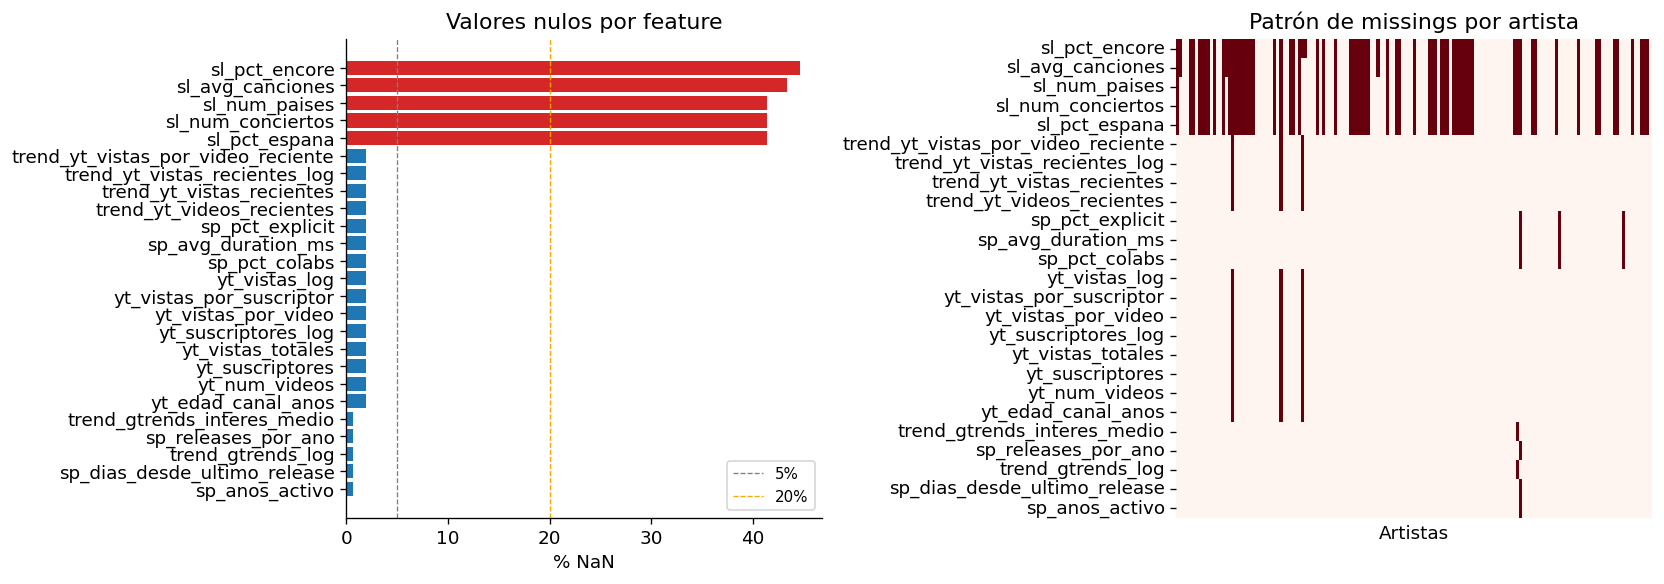


Features con >10% NaN:
sl_pct_encore        44.585987
sl_avg_canciones     43.312102
sl_num_paises        41.401274
sl_num_conciertos    41.401274
sl_pct_espana        41.401274


In [3]:
nan_pct = (df[FEATURES].isna().sum() / len(df) * 100).sort_values(ascending=False)
nan_pct = nan_pct[nan_pct > 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barplot % NaN por feature
colors = ['#d62728' if v > 30 else '#ff7f0e' if v > 10 else '#1f77b4' for v in nan_pct]
axes[0].barh(nan_pct.index[::-1], nan_pct.values[::-1], color=colors[::-1])
axes[0].axvline(5, color='grey', linestyle='--', linewidth=0.8, label='5%')
axes[0].axvline(20, color='orange', linestyle='--', linewidth=0.8, label='20%')
axes[0].set_xlabel('% NaN')
axes[0].set_title('Valores nulos por feature')
axes[0].legend(fontsize=9)

# Heatmap de missings por artista (solo features con NaN)
feat_con_nan = nan_pct.index.tolist()
miss_matrix  = df[feat_con_nan].isna().astype(int)
miss_matrix.index = df['nombre_buscado']
sns.heatmap(miss_matrix.T, cmap='Reds', cbar=False, ax=axes[1],
            xticklabels=False, yticklabels=True)
axes[1].set_title('Patrón de missings por artista')
axes[1].set_xlabel('Artistas')

plt.tight_layout()
plt.show()

print('\nFeatures con >10% NaN:')
print(nan_pct[nan_pct > 10].to_string())

## 3. Distribución del target

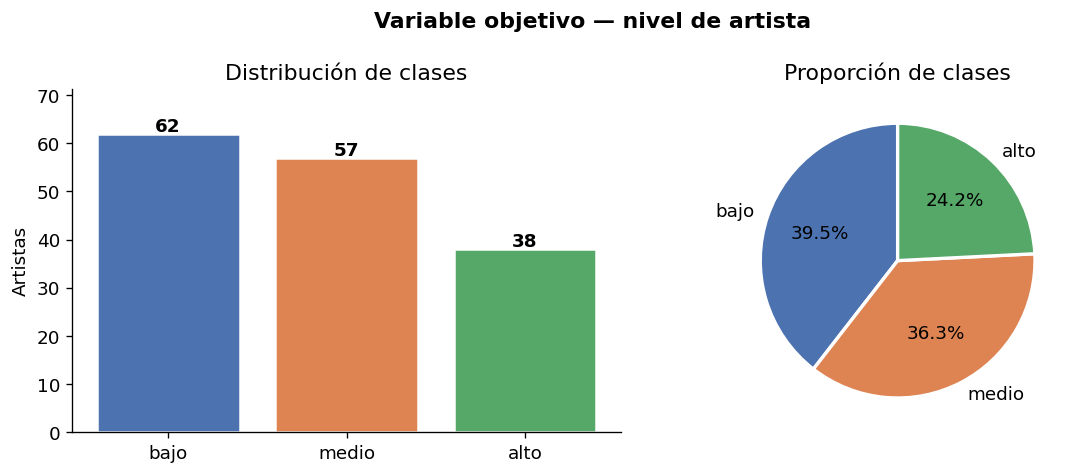

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

counts = df['nivel'].value_counts().reindex(ORDEN)
axes[0].bar(counts.index, counts.values,
            color=[PALETTE[n] for n in counts.index], edgecolor='white', linewidth=1.5)
for i, (nivel, v) in enumerate(counts.items()):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')
axes[0].set_title('Distribución de clases')
axes[0].set_ylabel('Artistas')
axes[0].set_ylim(0, counts.max() * 1.15)

axes[1].pie(counts.values, labels=counts.index,
            colors=[PALETTE[n] for n in counts.index],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporción de clases')

plt.suptitle('Variable objetivo — nivel de artista', fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Distribución de features

C:\Users\vicho\AppData\Local\Temp\ipykernel_13068\3799903462.py:16: UserWarning: Glyph 128192 (\N{DVD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\vicho\PROYECTOS\prediccion_musical_TFM\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128192 (\N{DVD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


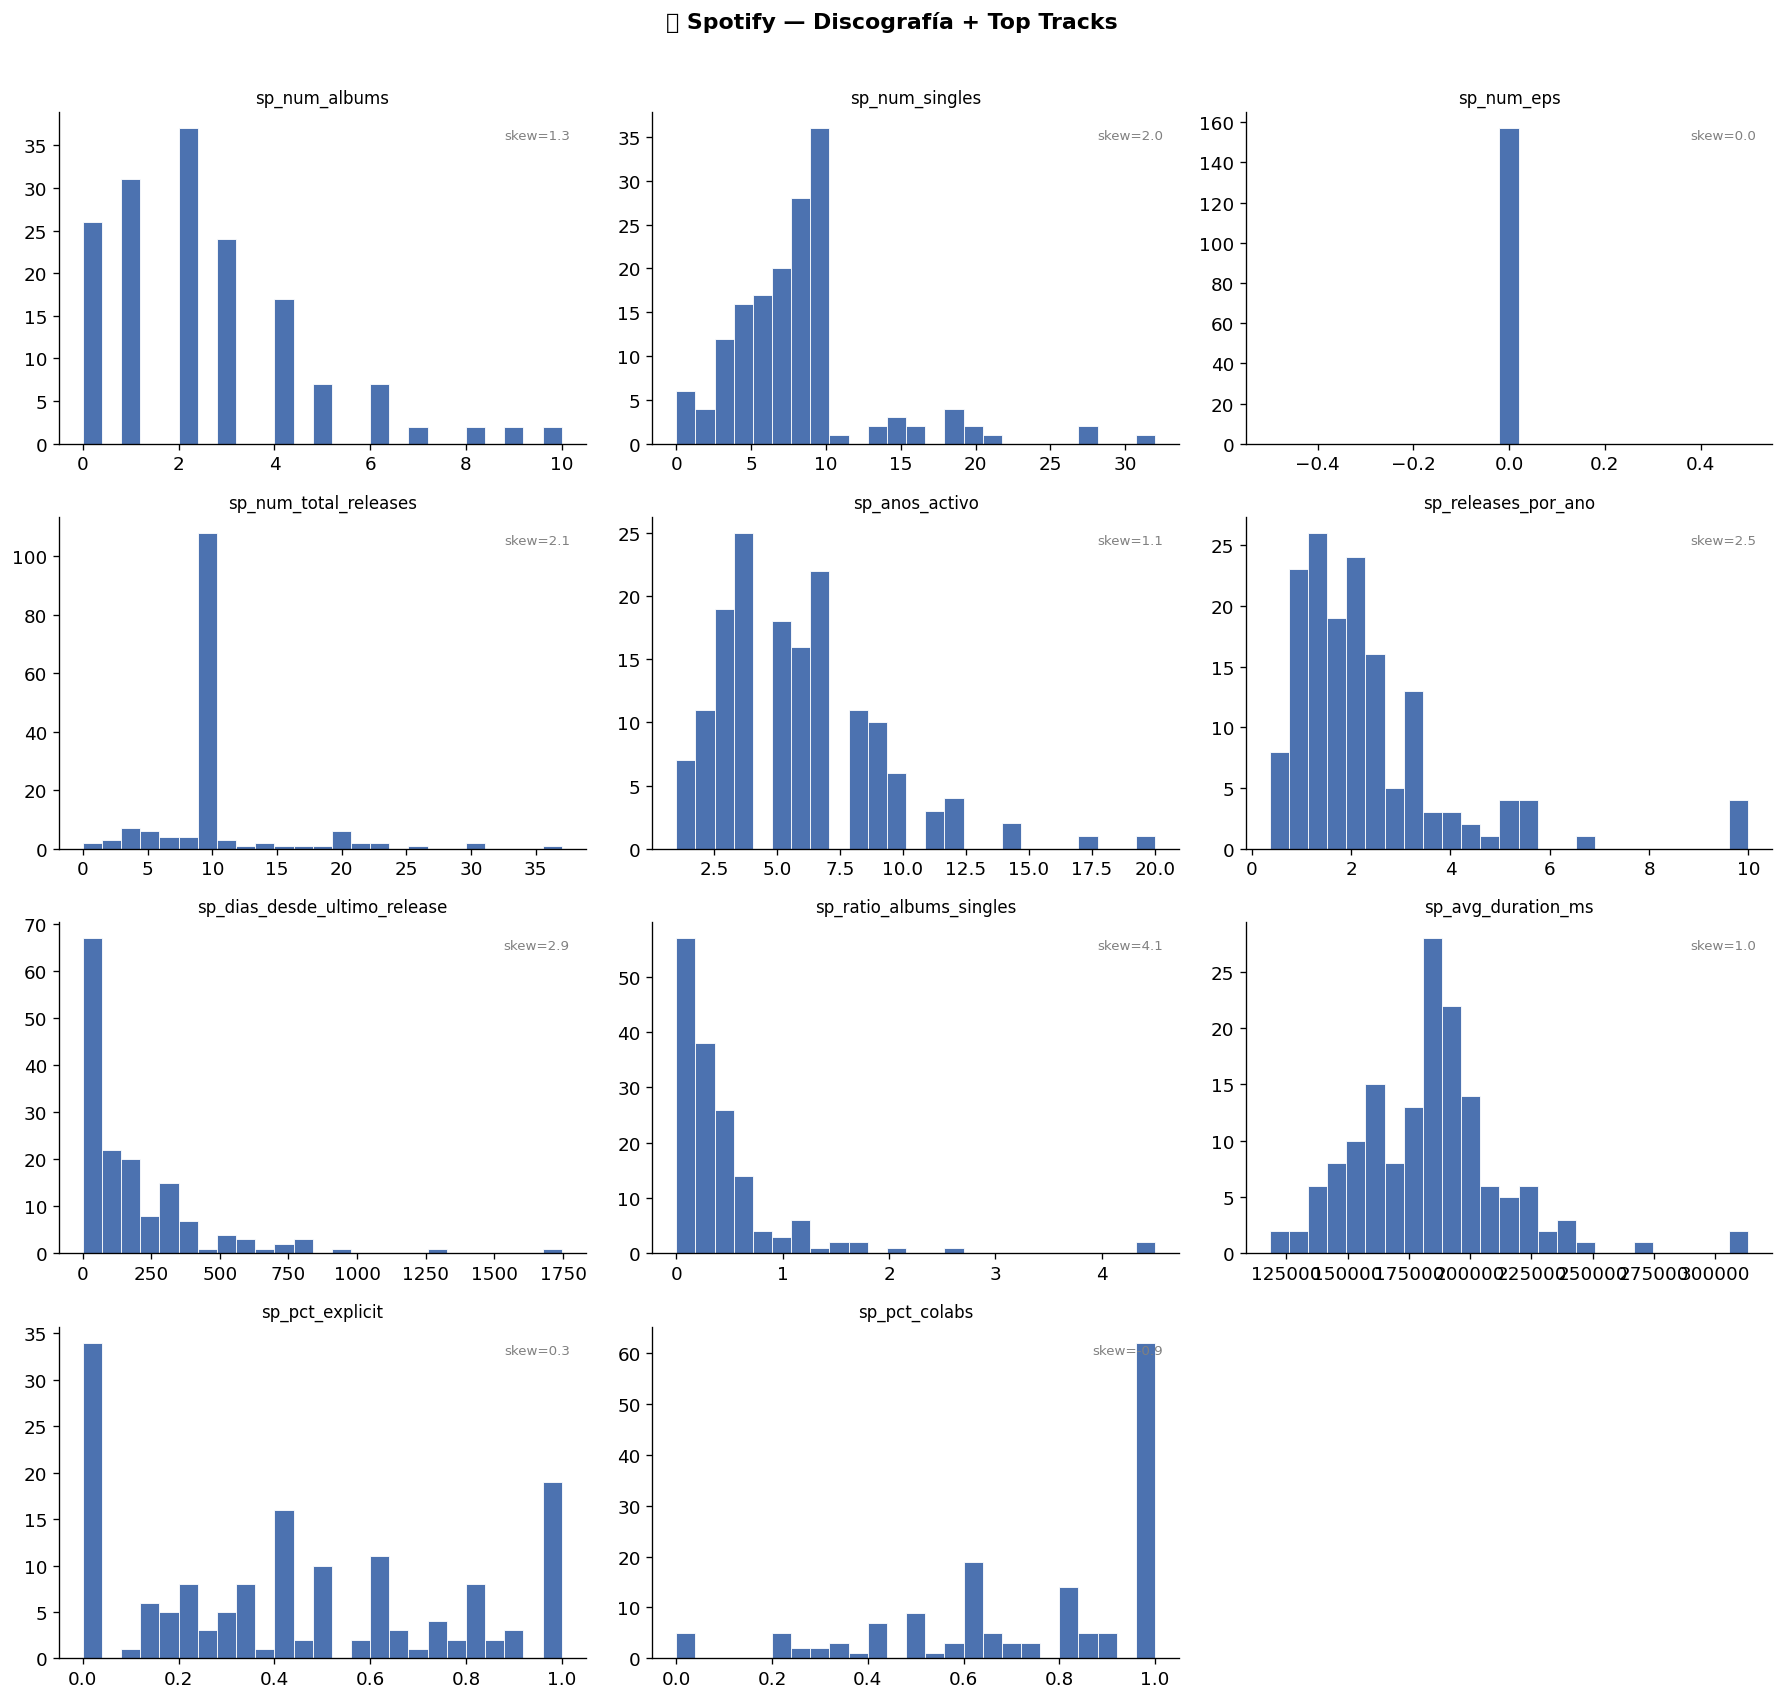

C:\Users\vicho\AppData\Local\Temp\ipykernel_13068\3799903462.py:16: UserWarning: Glyph 127925 (\N{MUSICAL NOTE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\vicho\PROYECTOS\prediccion_musical_TFM\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127925 (\N{MUSICAL NOTE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


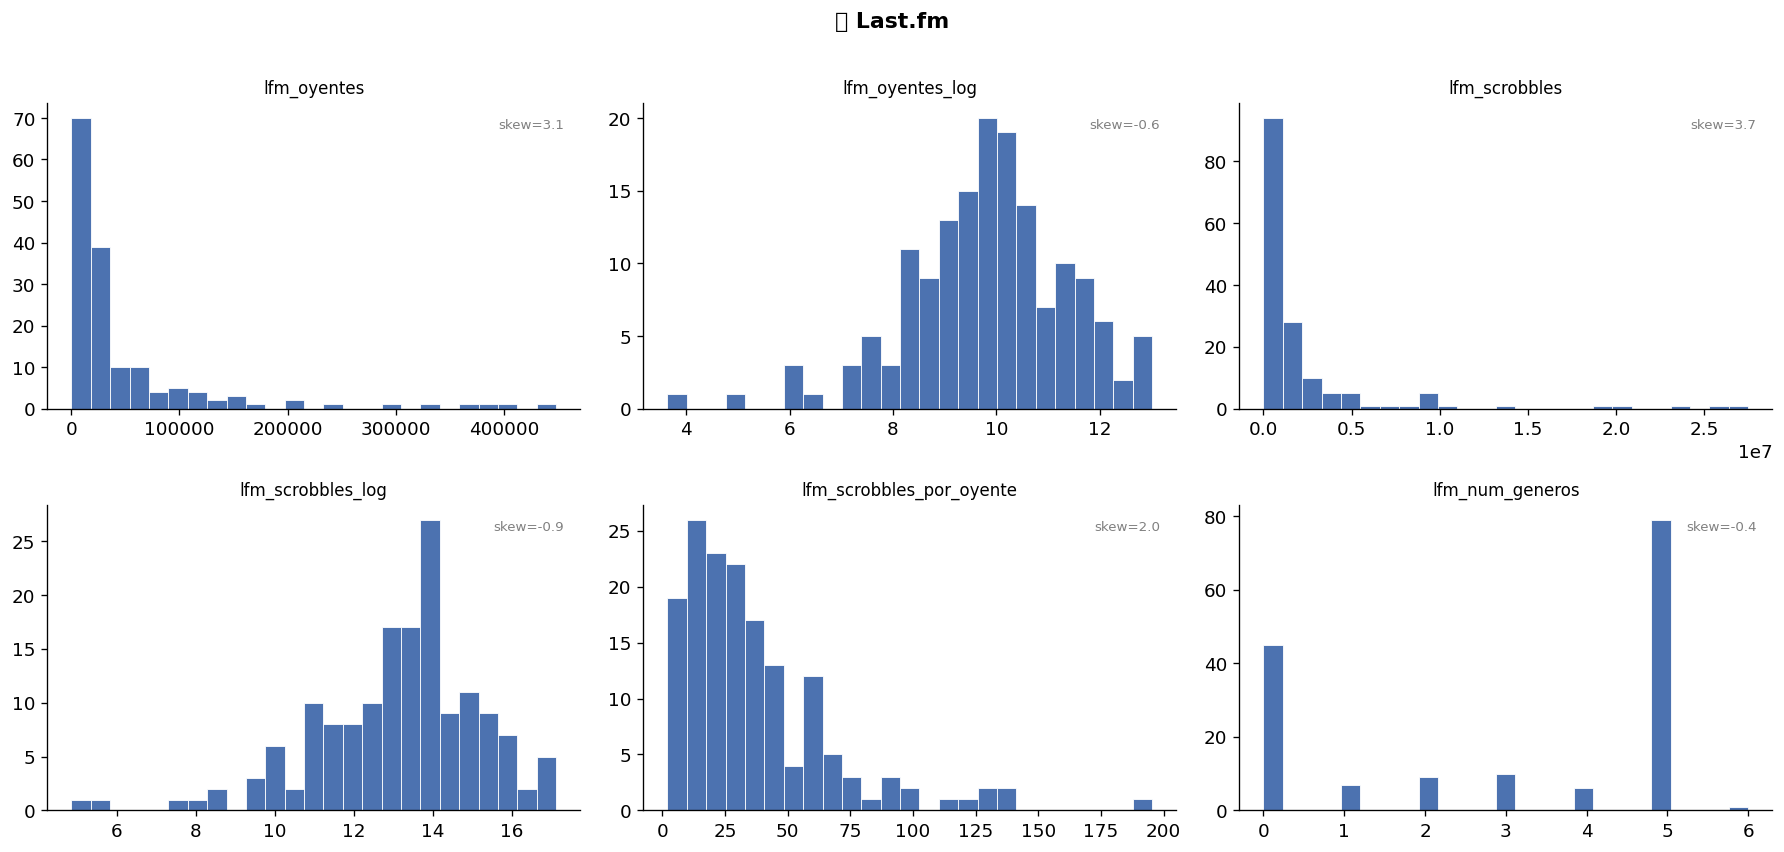

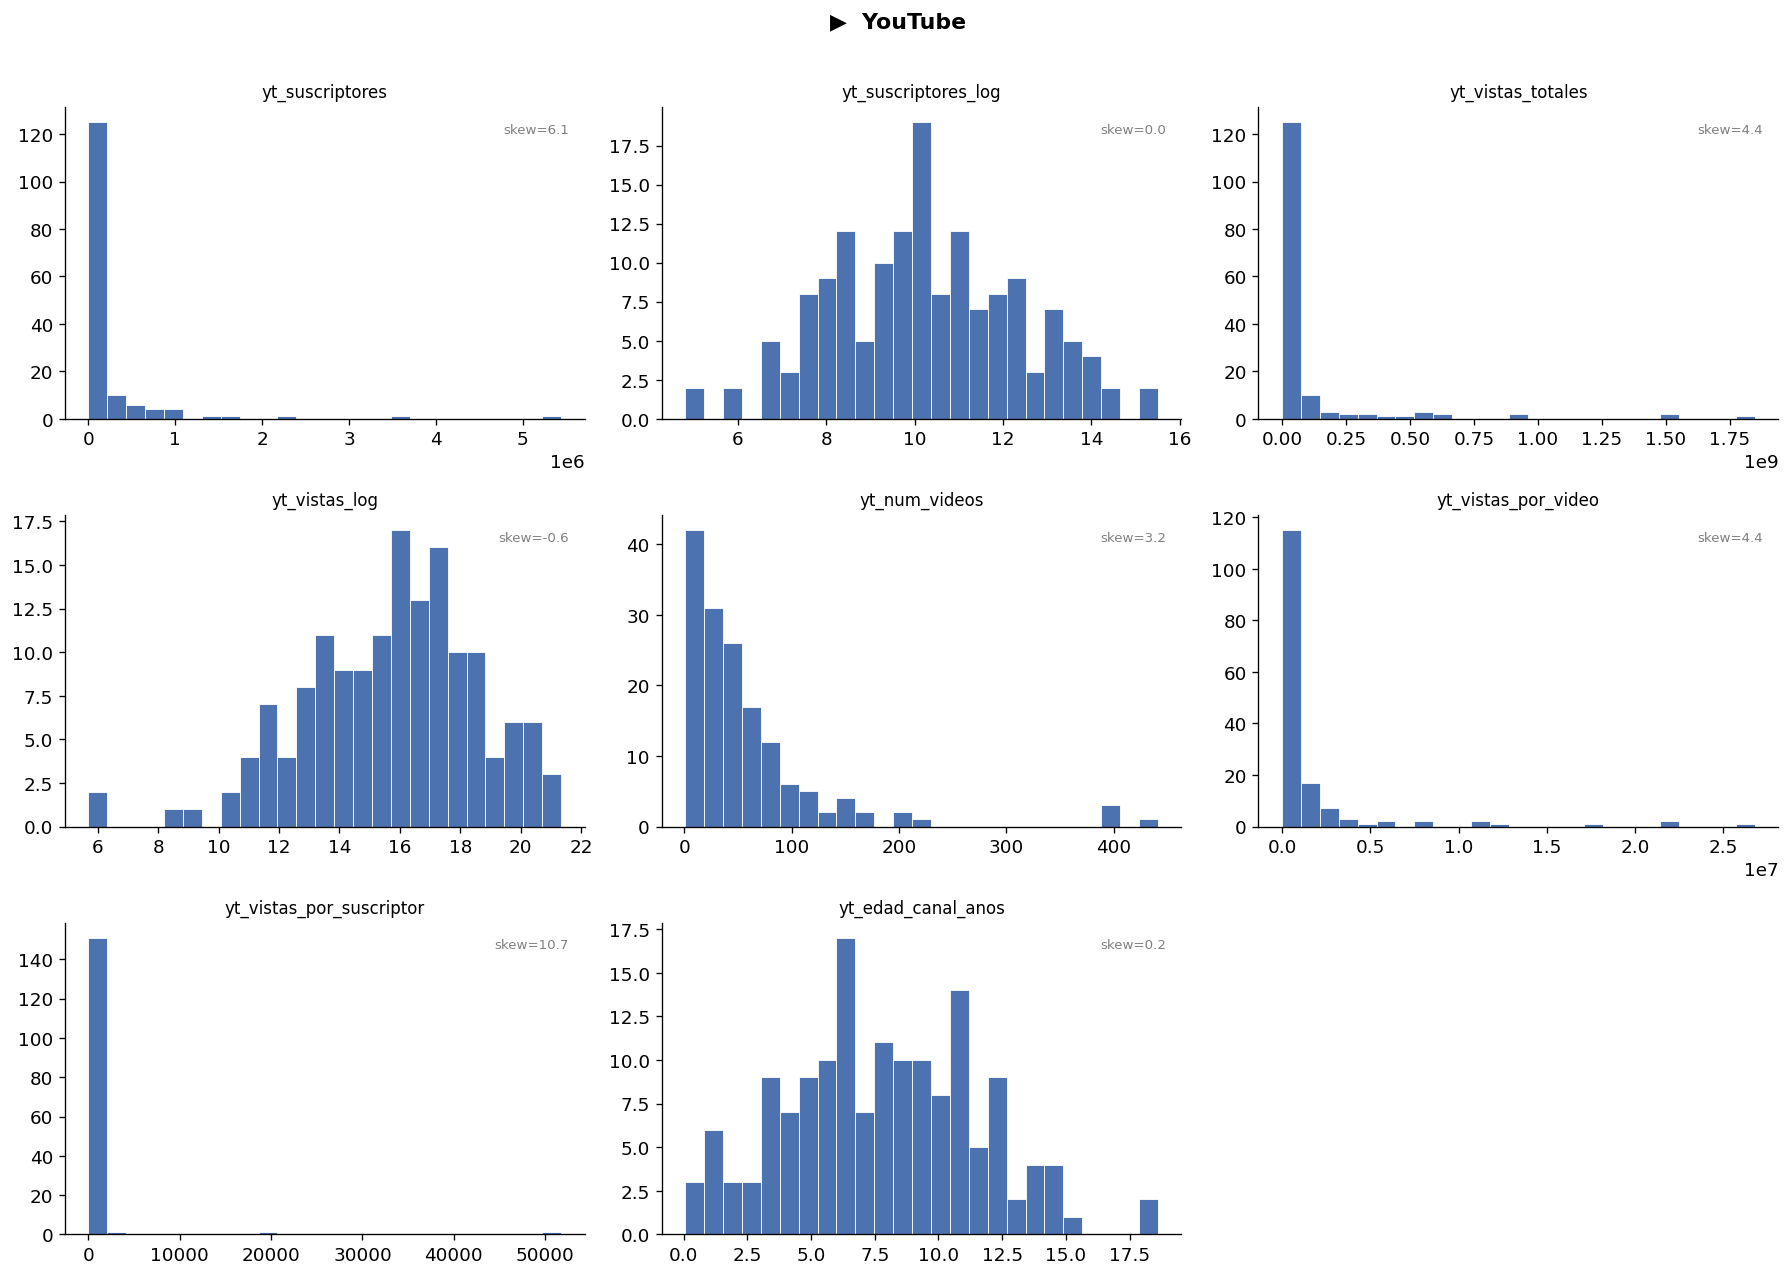

C:\Users\vicho\AppData\Local\Temp\ipykernel_13068\3799903462.py:16: UserWarning: Glyph 127908 (\N{MICROPHONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\vicho\PROYECTOS\prediccion_musical_TFM\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127908 (\N{MICROPHONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


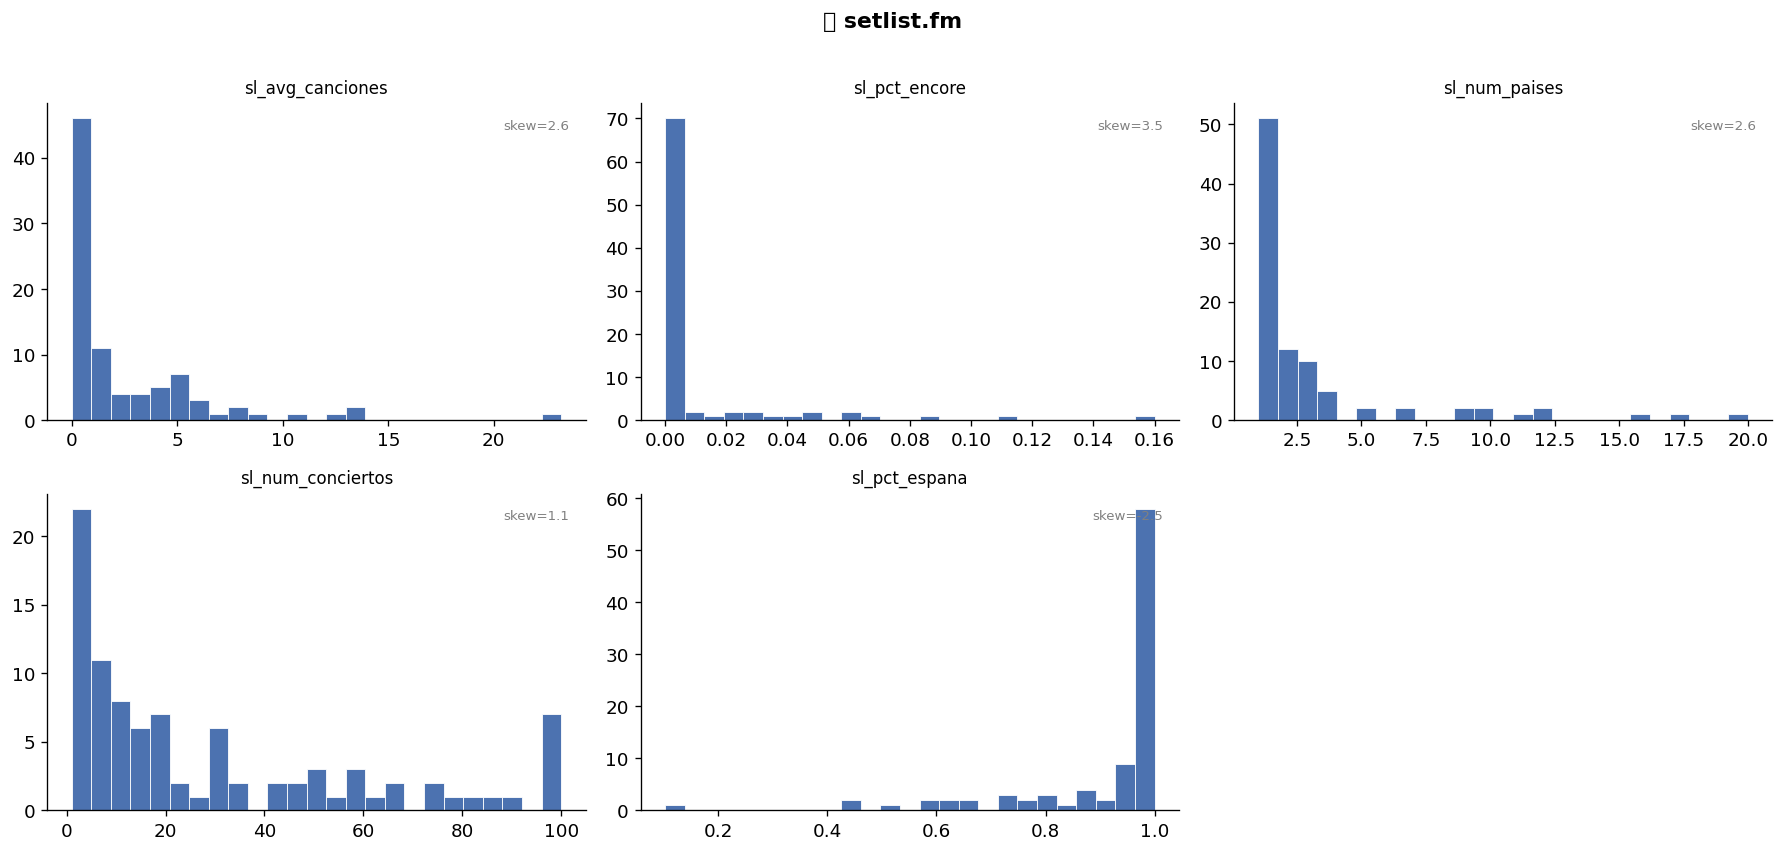

C:\Users\vicho\AppData\Local\Temp\ipykernel_13068\3799903462.py:16: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\vicho\PROYECTOS\prediccion_musical_TFM\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


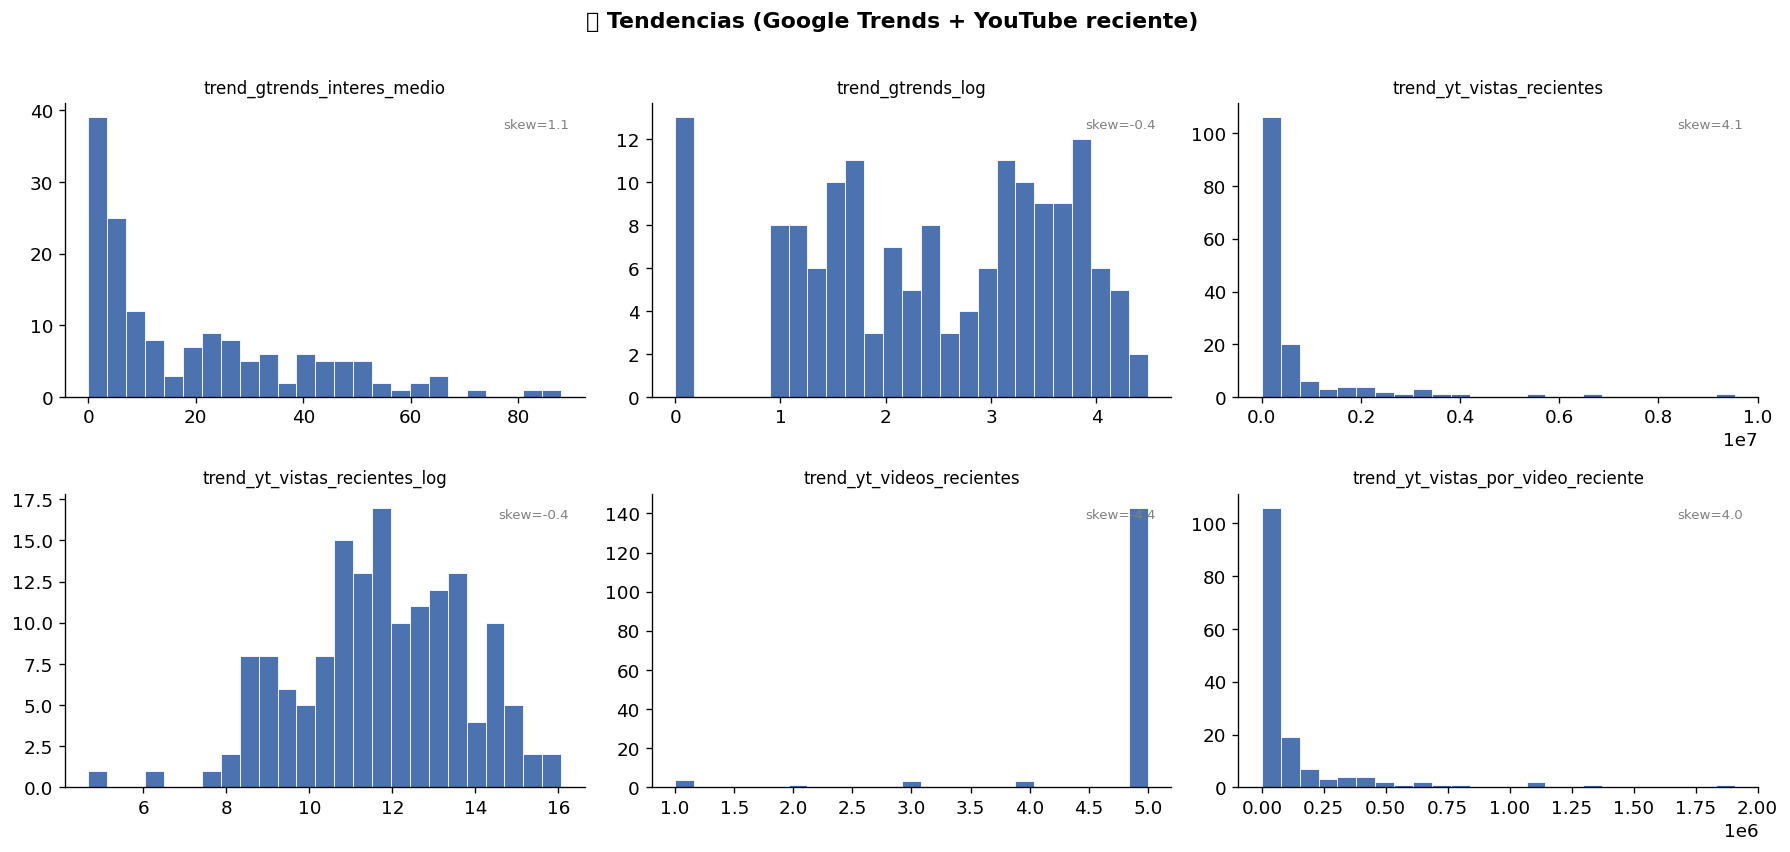

In [5]:
def plot_feature_group(features, title, ncols=3):
    nrows = int(np.ceil(len(features) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows))
    axes = axes.flatten()
    for i, feat in enumerate(features):
        data = df[feat].dropna()
        axes[i].hist(data, bins=25, color='#4C72B0', edgecolor='white', linewidth=0.5)
        axes[i].set_title(feat, fontsize=10)
        axes[i].set_xlabel('')
        skew = data.skew()
        axes[i].text(0.97, 0.95, f'skew={skew:.1f}', transform=axes[i].transAxes,
                     ha='right', va='top', fontsize=8, color='grey')
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle(title, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

plot_feature_group(FEAT_SP,    '📀 Spotify — Discografía + Top Tracks')
plot_feature_group(FEAT_LFM,   '🎵 Last.fm')
plot_feature_group(FEAT_YT,    '▶️  YouTube')
plot_feature_group(FEAT_SL,    '🎤 setlist.fm')
plot_feature_group(FEAT_TREND, '📈 Tendencias (Google Trends + YouTube reciente)')

## 5. Features vs Target — Boxplots

C:\Users\vicho\AppData\Local\Temp\ipykernel_13068\3023941207.py:18: UserWarning: Glyph 128192 (\N{DVD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\vicho\PROYECTOS\prediccion_musical_TFM\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128192 (\N{DVD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


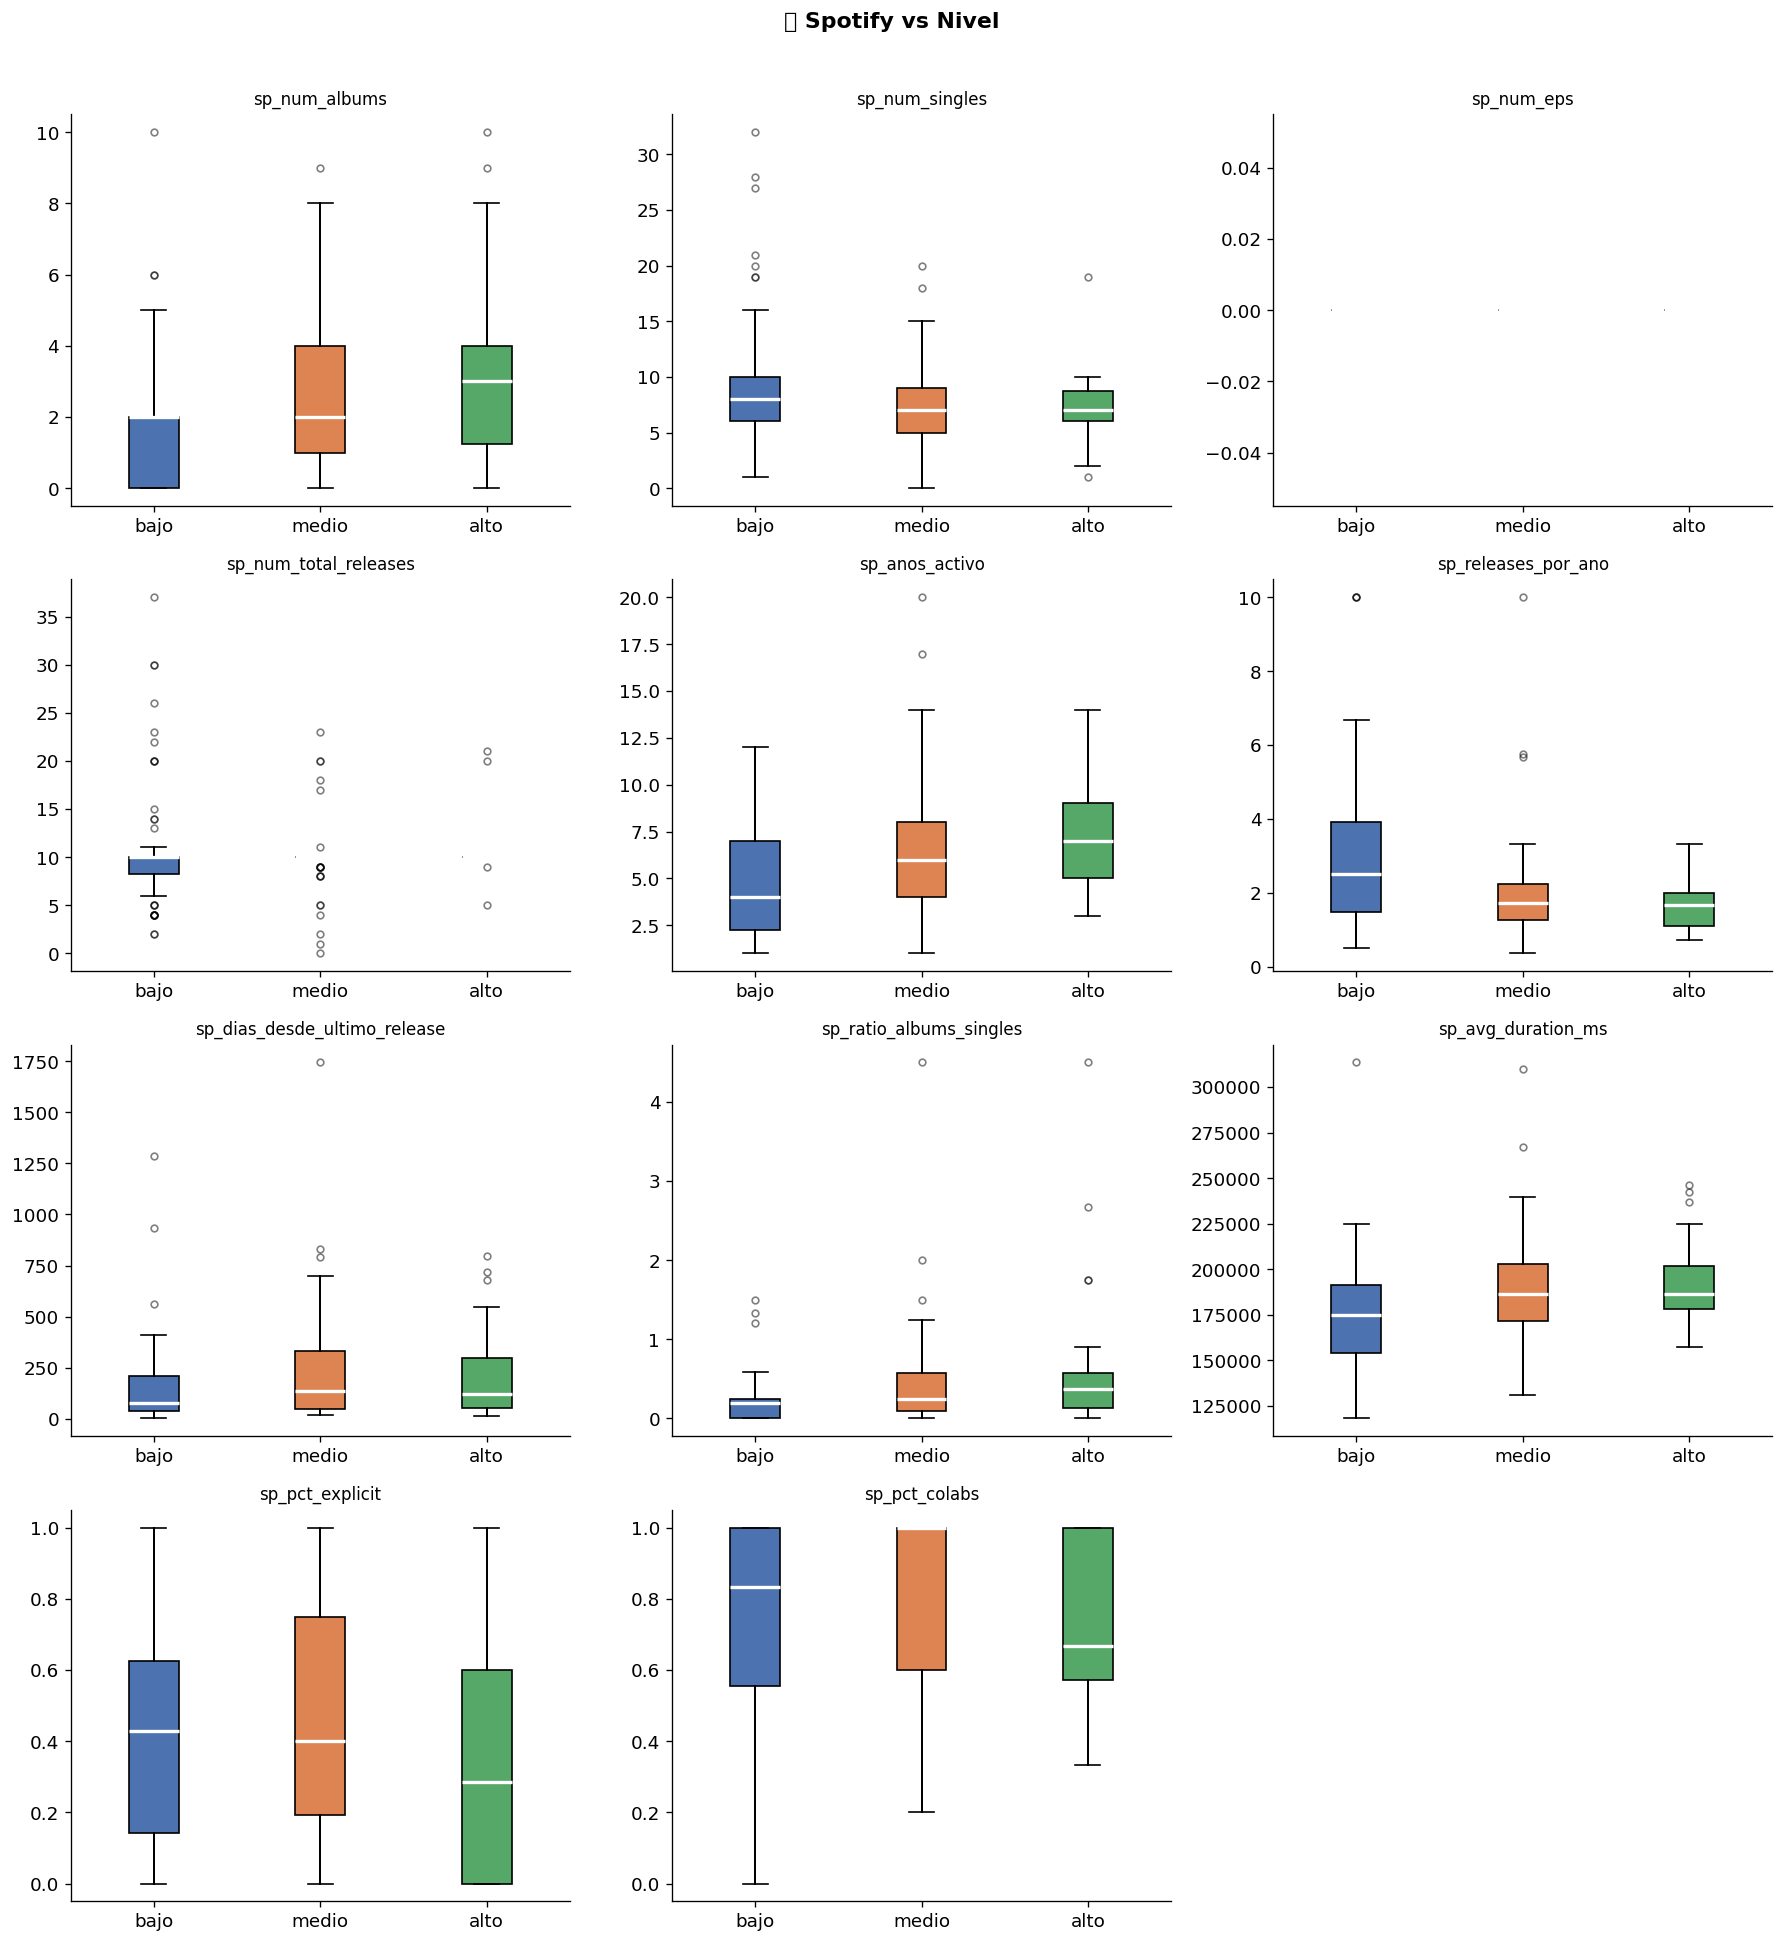

C:\Users\vicho\AppData\Local\Temp\ipykernel_13068\3023941207.py:18: UserWarning: Glyph 127925 (\N{MUSICAL NOTE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\vicho\PROYECTOS\prediccion_musical_TFM\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127925 (\N{MUSICAL NOTE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


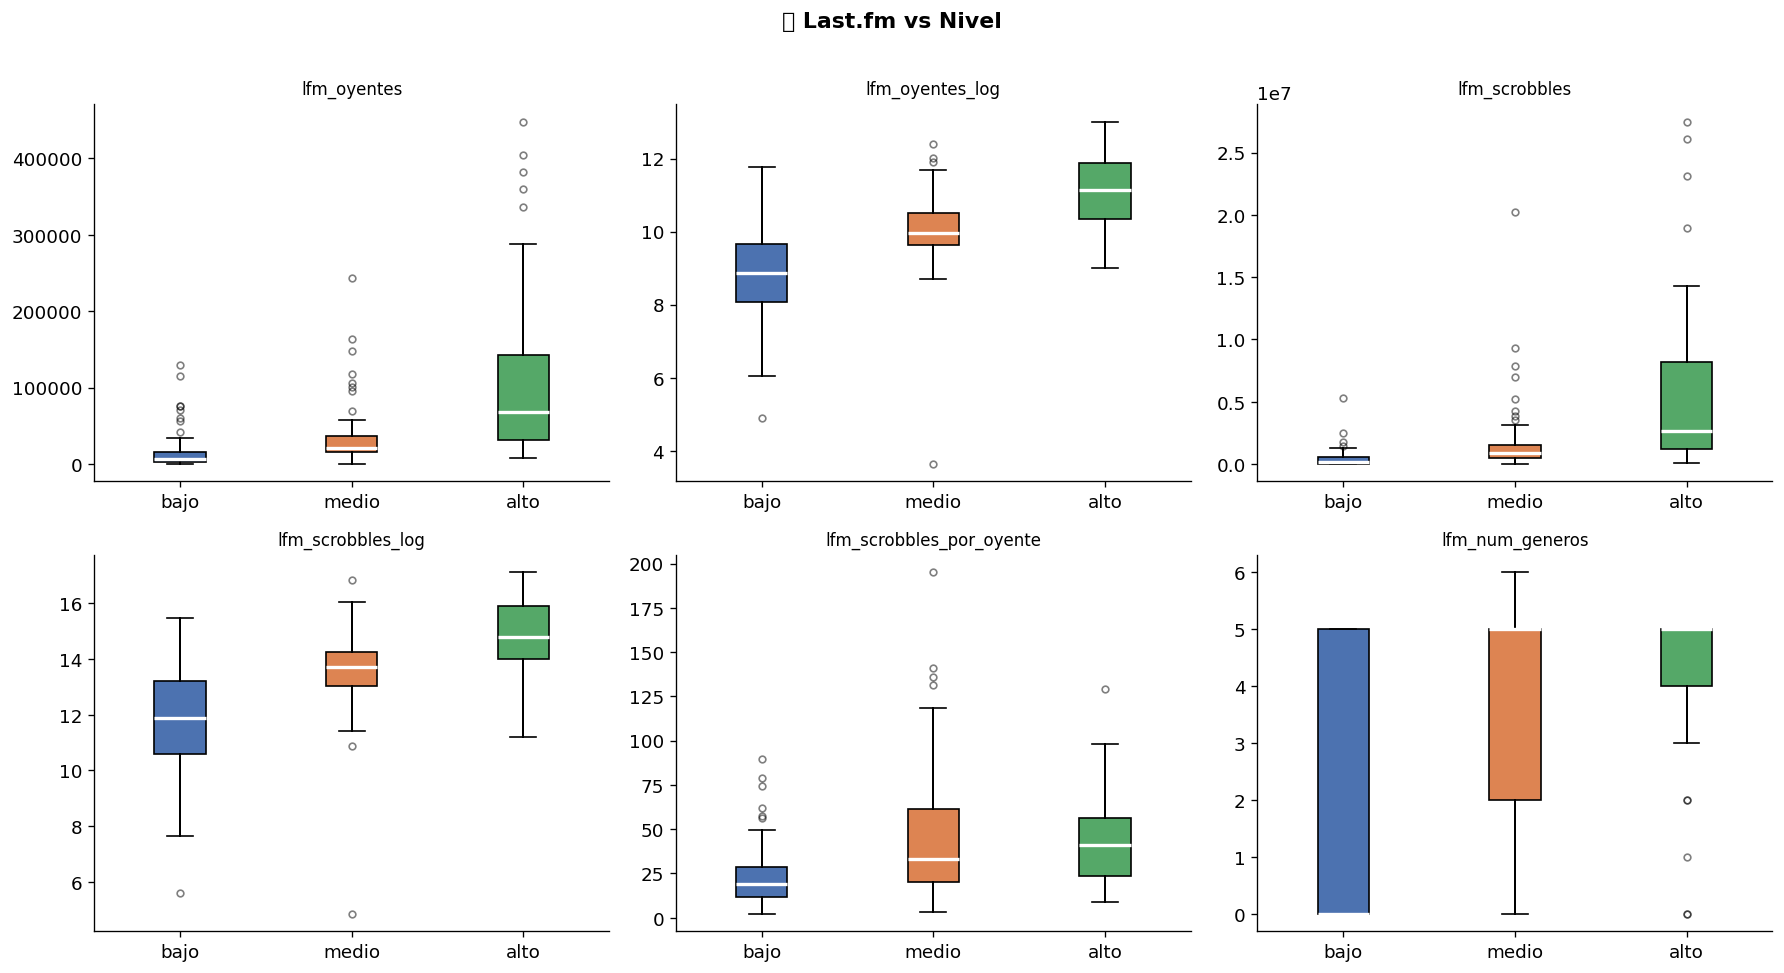

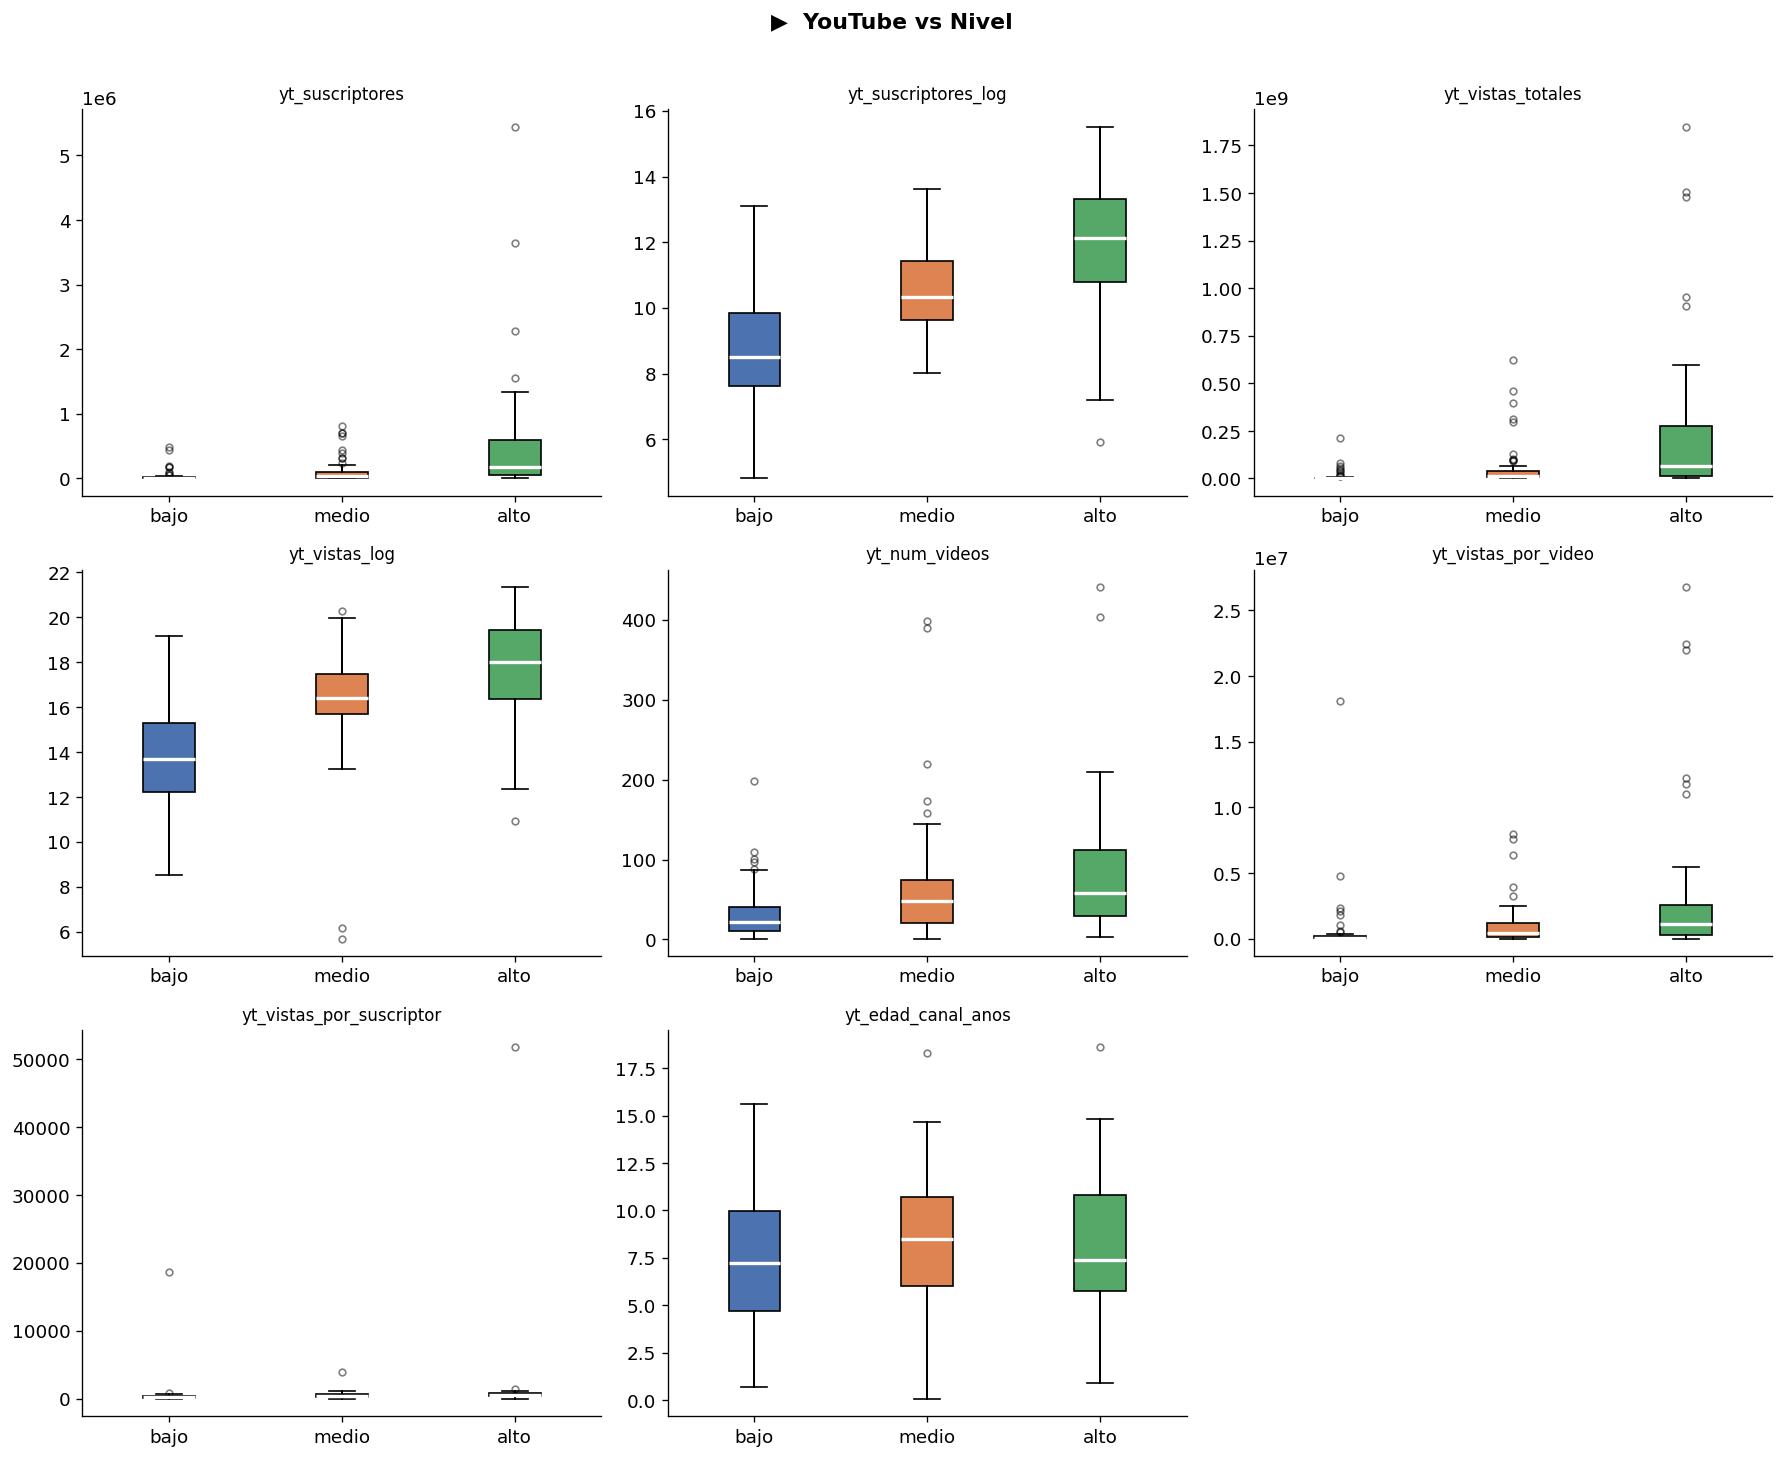

C:\Users\vicho\AppData\Local\Temp\ipykernel_13068\3023941207.py:18: UserWarning: Glyph 127908 (\N{MICROPHONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\vicho\PROYECTOS\prediccion_musical_TFM\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127908 (\N{MICROPHONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


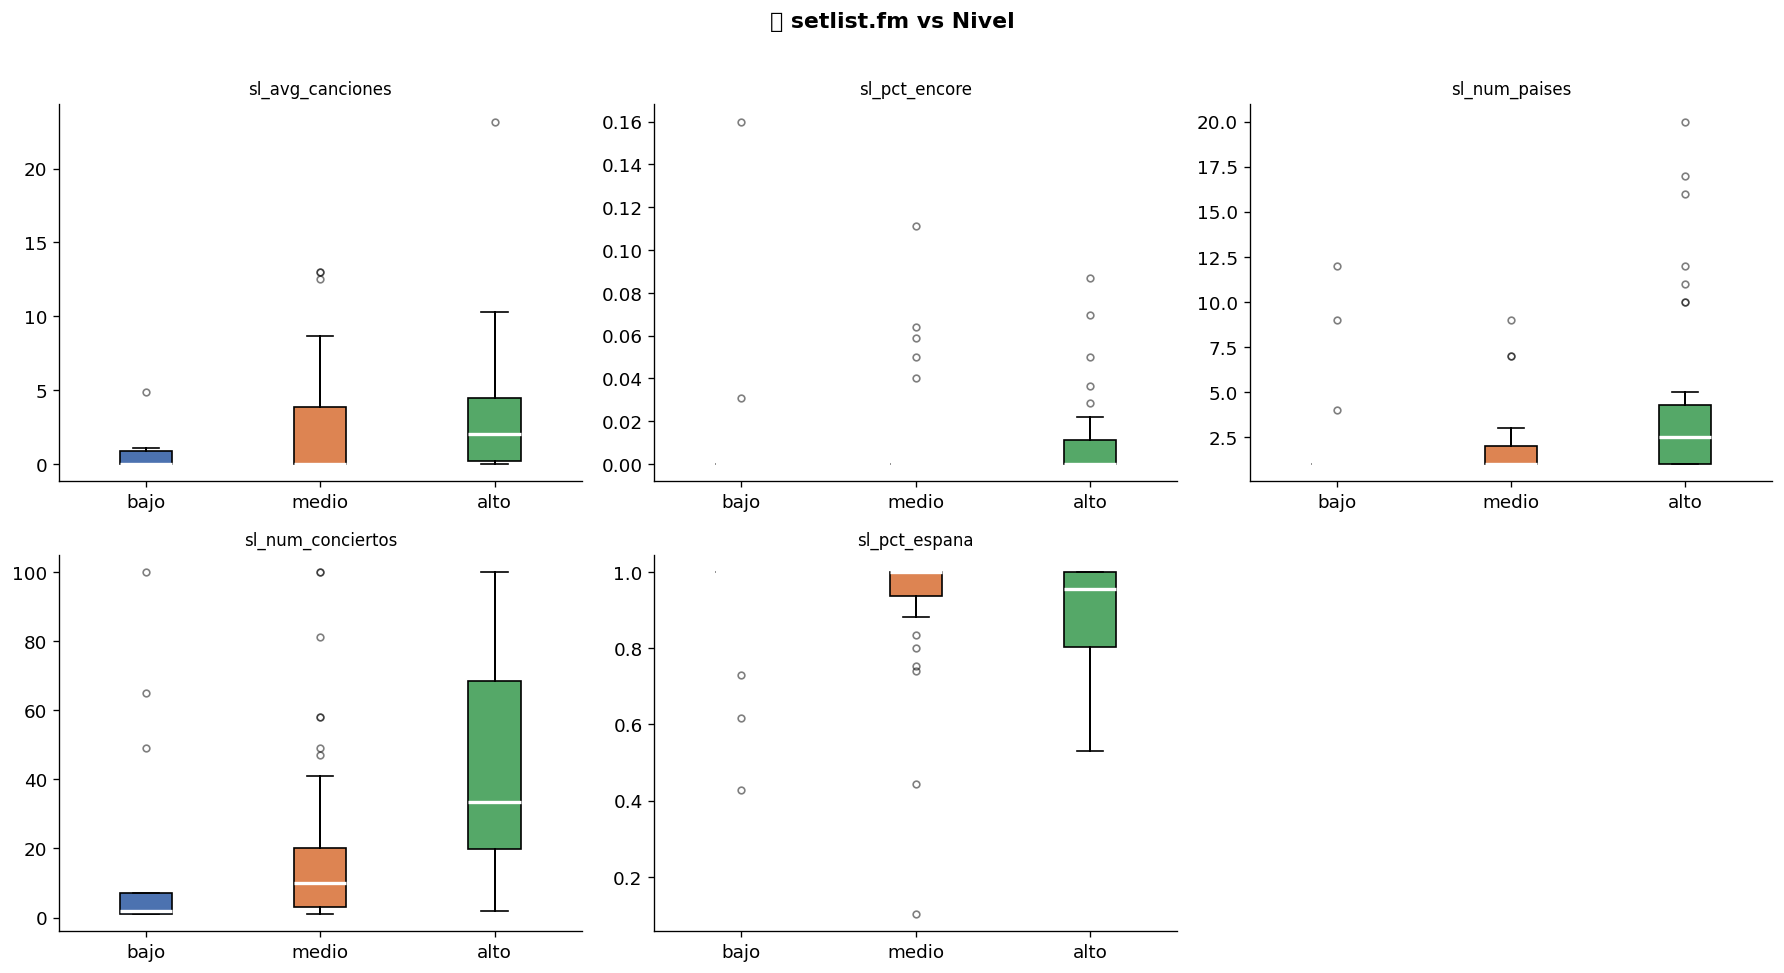

C:\Users\vicho\AppData\Local\Temp\ipykernel_13068\3023941207.py:18: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\vicho\PROYECTOS\prediccion_musical_TFM\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


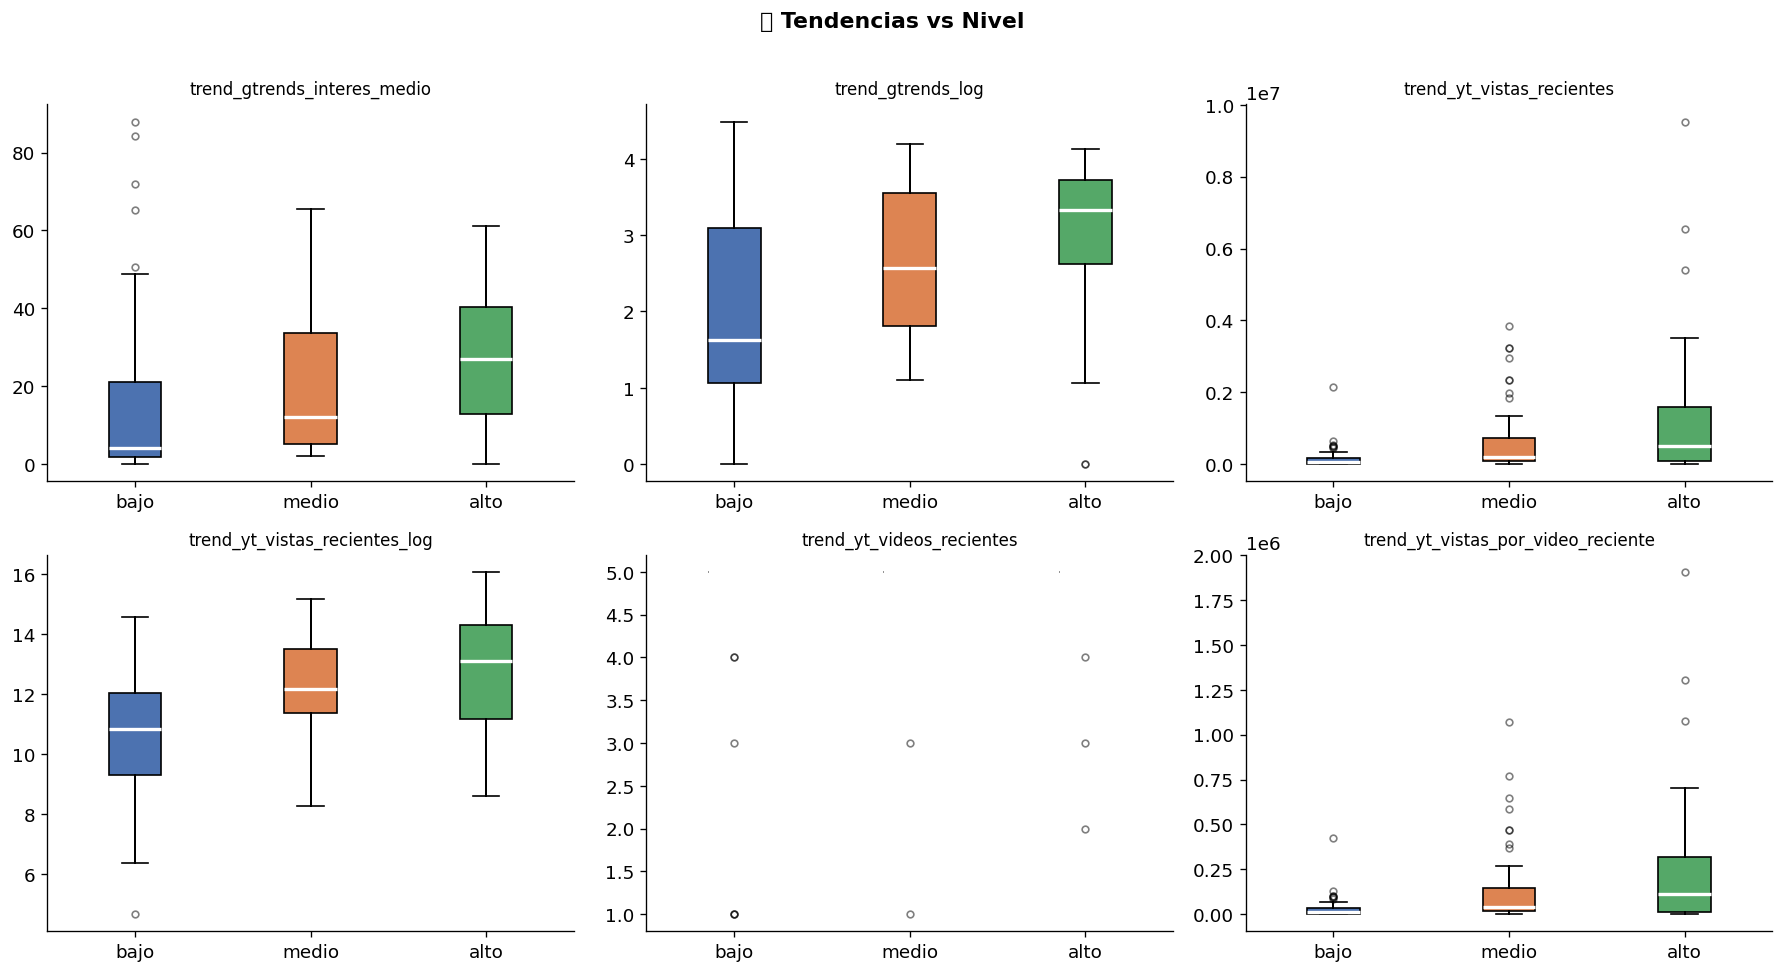

In [6]:
def plot_boxplots_vs_target(features, title, ncols=3):
    nrows = int(np.ceil(len(features) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = axes.flatten()
    for i, feat in enumerate(features):
        grupos = [df.loc[df['nivel'] == n, feat].dropna() for n in ORDEN]
        bp = axes[i].boxplot(grupos, patch_artist=True,
                             medianprops={'color': 'white', 'linewidth': 2},
                             whiskerprops={'linewidth': 1.2},
                             flierprops={'marker': 'o', 'markersize': 4, 'alpha': 0.5})
        for patch, nivel in zip(bp['boxes'], ORDEN):
            patch.set_facecolor(PALETTE[nivel])
        axes[i].set_xticklabels(ORDEN)
        axes[i].set_title(feat, fontsize=10)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle(title, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

plot_boxplots_vs_target(FEAT_SP,    '📀 Spotify vs Nivel')
plot_boxplots_vs_target(FEAT_LFM,   '🎵 Last.fm vs Nivel')
plot_boxplots_vs_target(FEAT_YT,    '▶️  YouTube vs Nivel')
plot_boxplots_vs_target(FEAT_SL,    '🎤 setlist.fm vs Nivel')
plot_boxplots_vs_target(FEAT_TREND, '📈 Tendencias vs Nivel')

## 6. Poder discriminativo — Kruskal-Wallis

c:\Users\vicho\PROYECTOS\prediccion_musical_TFM\.venv\Lib\site-packages\scipy\stats\_stats_py.py:8492: RuntimeWarning: invalid value encountered in scalar divide
  h /= ties


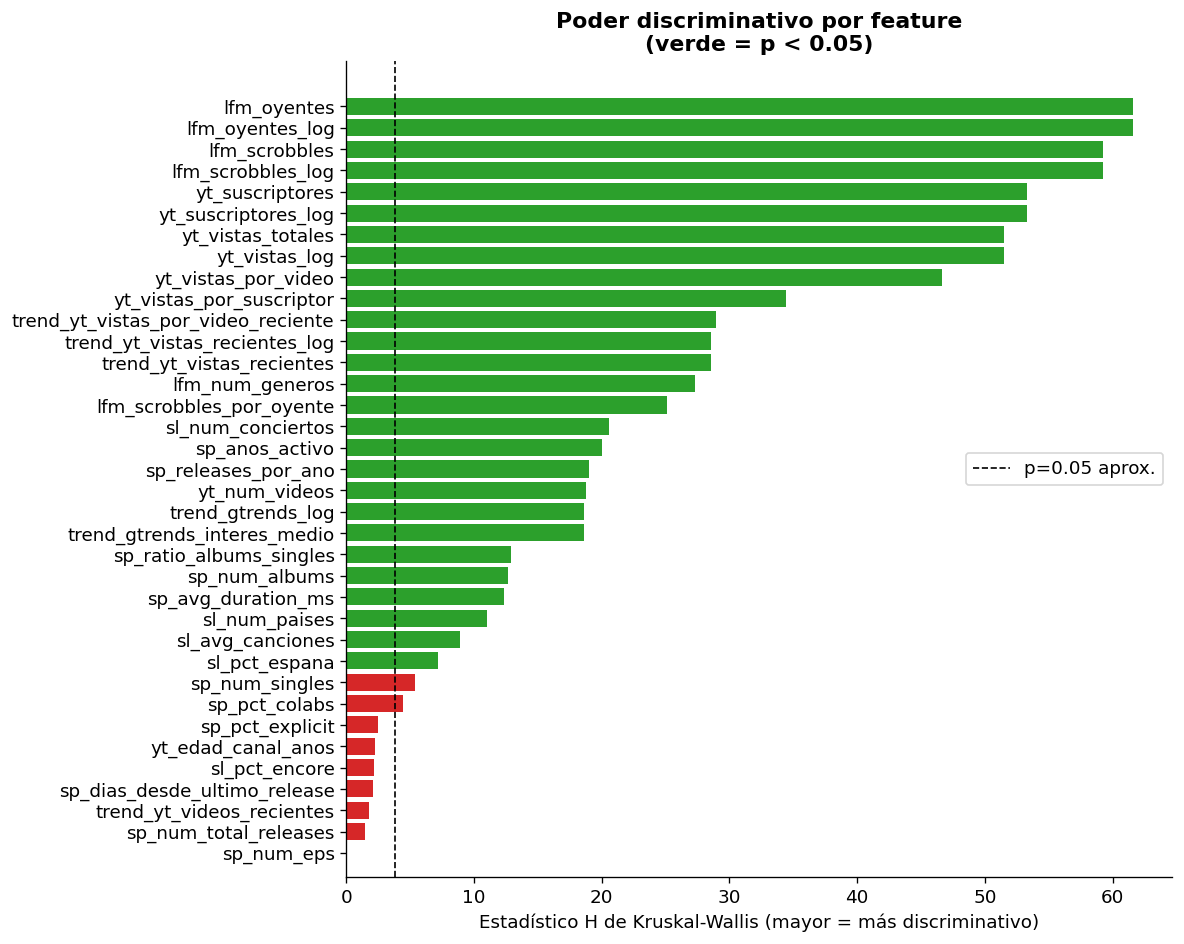


Features significativas (p<0.05): 27 / 36

Top 10 más discriminativas:
                 feature    H_stat      p_value
             lfm_oyentes 61.595243 4.214663e-14
         lfm_oyentes_log 61.595243 4.214663e-14
           lfm_scrobbles 59.228720 1.376090e-13
       lfm_scrobbles_log 59.228720 1.376090e-13
         yt_suscriptores 53.253468 2.729960e-12
     yt_suscriptores_log 53.253468 2.729960e-12
       yt_vistas_totales 51.520433 6.493520e-12
           yt_vistas_log 51.520433 6.493520e-12
     yt_vistas_por_video 46.614112 7.548736e-11
yt_vistas_por_suscriptor 34.455622 3.296528e-08


In [7]:
from scipy import stats

resultados = []
for feat in FEATURES:
    grupos = [df.loc[df['nivel'] == n, feat].dropna().values for n in ORDEN]
    if all(len(g) > 2 for g in grupos):
        stat, p = stats.kruskal(*grupos)
        resultados.append({'feature': feat, 'H_stat': stat, 'p_value': p})

kw = pd.DataFrame(resultados).sort_values('H_stat', ascending=False)
kw['significativa'] = kw['p_value'] < 0.05

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#2ca02c' if sig else '#d62728' for sig in kw['significativa']]
bars = ax.barh(kw['feature'][::-1], kw['H_stat'][::-1], color=colors[::-1])
ax.axvline(3.84, color='black', linestyle='--', linewidth=1, label='p=0.05 aprox.')
ax.set_xlabel('Estadístico H de Kruskal-Wallis (mayor = más discriminativo)')
ax.set_title('Poder discriminativo por feature\n(verde = p < 0.05)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f'\nFeatures significativas (p<0.05): {kw["significativa"].sum()} / {len(kw)}')
print('\nTop 10 más discriminativas:')
print(kw[['feature', 'H_stat', 'p_value']].head(10).to_string(index=False))

## 7. Matriz de correlaciones

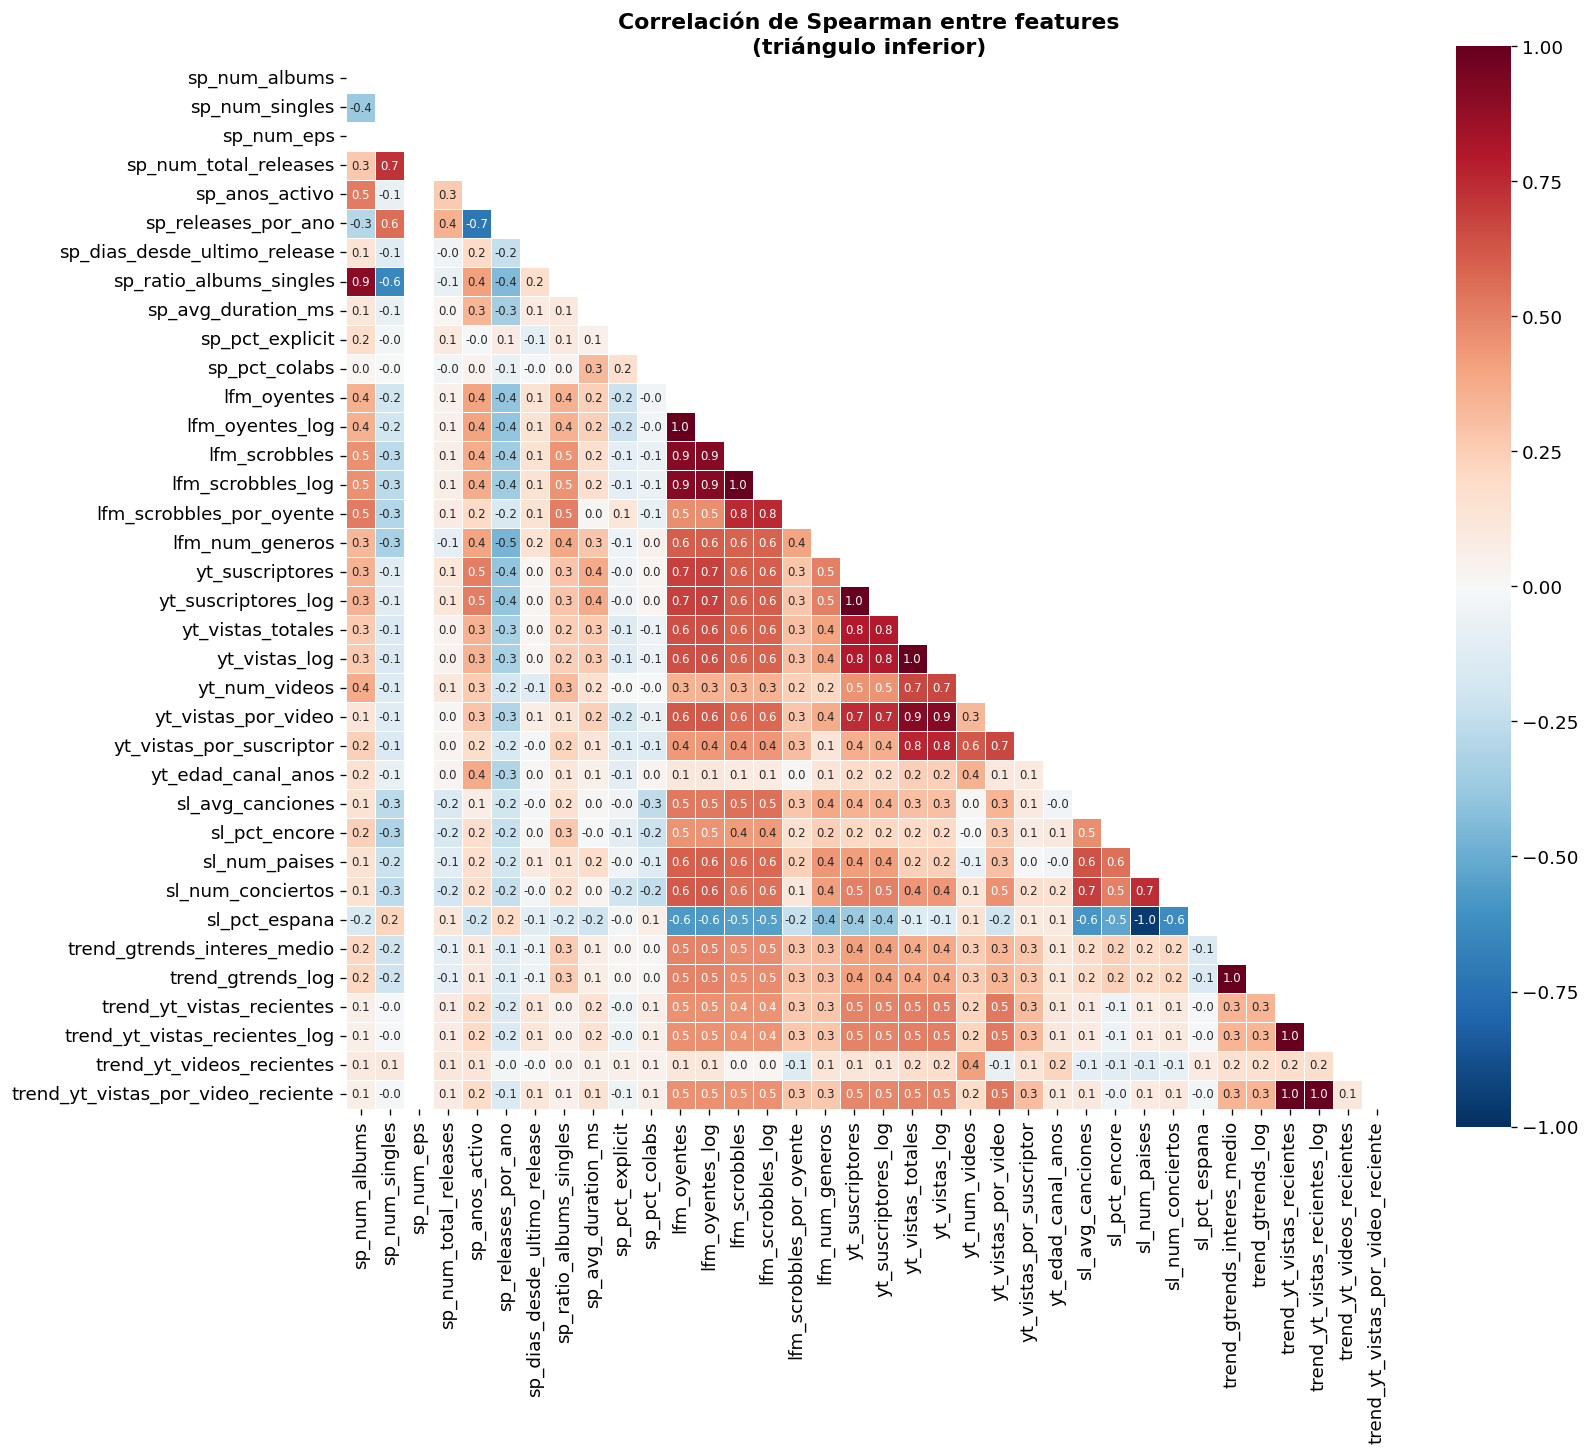

Pares con correlación |r| > 0.85:
                            feat_a                        feat_b      corr
                   lfm_oyentes_log                   lfm_oyentes  1.000000
               yt_suscriptores_log               yt_suscriptores  1.000000
                 lfm_scrobbles_log                 lfm_scrobbles  1.000000
                     yt_vistas_log             yt_vistas_totales  1.000000
                 trend_gtrends_log   trend_gtrends_interes_medio  1.000000
     trend_yt_vistas_recientes_log     trend_yt_vistas_recientes  1.000000
trend_yt_vistas_por_video_reciente     trend_yt_vistas_recientes  0.996119
trend_yt_vistas_por_video_reciente trend_yt_vistas_recientes_log  0.996119
                     lfm_scrobbles                   lfm_oyentes  0.913494
                 lfm_scrobbles_log                   lfm_oyentes  0.913494
                     lfm_scrobbles               lfm_oyentes_log  0.913494
                 lfm_scrobbles_log               lfm_oyentes_log  

In [8]:
# Solo features con menos del 50% de NaN para que la correlación sea representativa
feat_validas = [f for f in FEATURES if df[f].isna().mean() < 0.5]
corr = df[feat_validas].corr(method='spearman')

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, cmap='RdBu_r', center=0,
    vmin=-1, vmax=1, annot=True, fmt='.1f',
    annot_kws={'size': 7}, linewidths=0.3,
    square=True, ax=ax
)
ax.set_title('Correlación de Spearman entre features\n(triángulo inferior)', fontweight='bold')
plt.tight_layout()
plt.show()

# Pares muy correlacionados (>0.85, excluyendo diagonal y pares raw/log)
corr_pairs = (
    corr.where(mask == False)
    .stack()
    .reset_index()
    .rename(columns={'level_0': 'feat_a', 'level_1': 'feat_b', 0: 'corr'})
)
altas = corr_pairs[corr_pairs['corr'].abs() > 0.85].sort_values('corr', ascending=False)
print('Pares con correlación |r| > 0.85:')
print(altas.to_string(index=False))

## 8. Correlación con el target

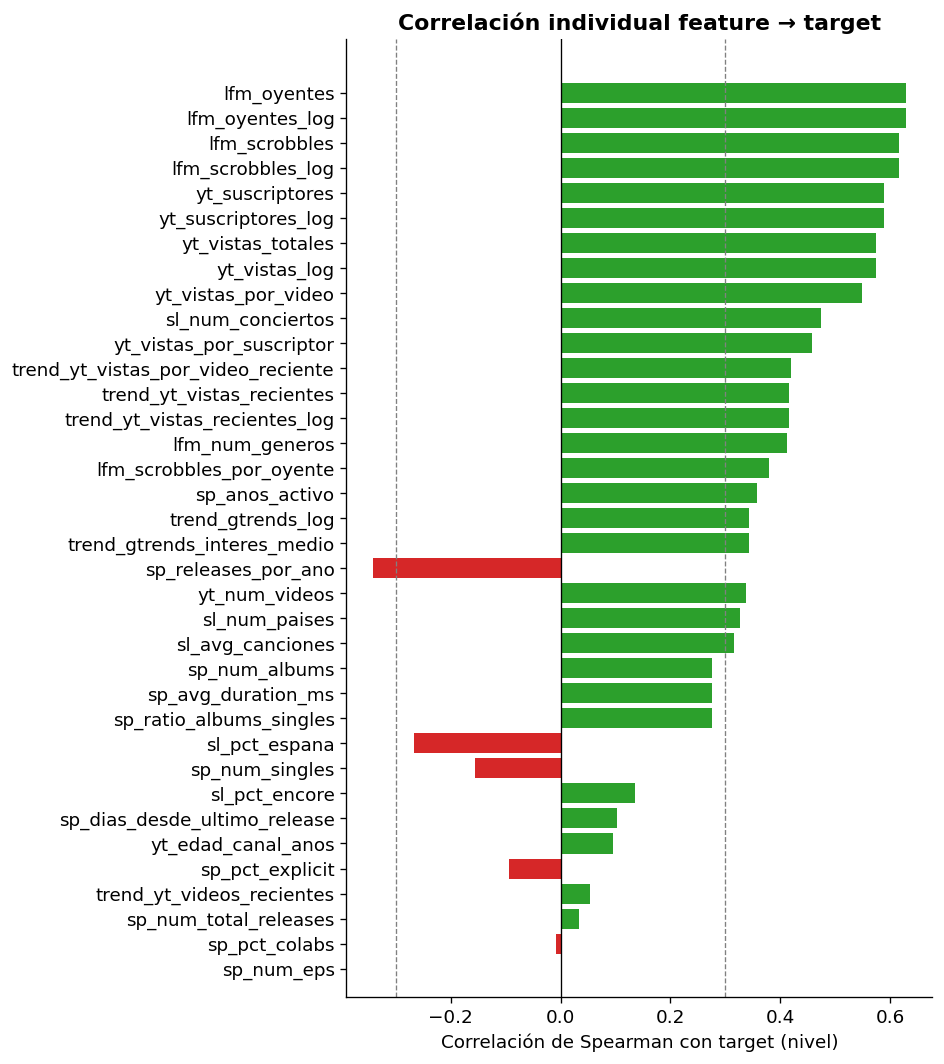

Top 10 features más correlacionadas con el target:
lfm_oyentes            0.627840
lfm_oyentes_log        0.627840
lfm_scrobbles          0.615428
lfm_scrobbles_log      0.615428
yt_suscriptores        0.587814
yt_suscriptores_log    0.587814
yt_vistas_totales      0.573183
yt_vistas_log          0.573183
yt_vistas_por_video    0.548094
sl_num_conciertos      0.473809


In [9]:
corr_target = (
    df[feat_validas + ['target']]
    .corr(method='spearman')['target']
    .drop('target')
    .sort_values(key=abs, ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 9))
colors = ['#2ca02c' if v > 0 else '#d62728' for v in corr_target]
ax.barh(corr_target.index[::-1], corr_target.values[::-1], color=colors[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.axvline(0.3,  color='grey', linestyle='--', linewidth=0.8)
ax.axvline(-0.3, color='grey', linestyle='--', linewidth=0.8)
ax.set_xlabel('Correlación de Spearman con target (nivel)')
ax.set_title('Correlación individual feature → target', fontweight='bold')
plt.tight_layout()
plt.show()

print('Top 10 features más correlacionadas con el target:')
print(corr_target.head(10).to_string())

## 9. Outliers — Z-score

In [10]:
from scipy.stats import zscore

z = df[feat_validas].apply(zscore, nan_policy='omit').abs()
outliers = (z > 3).sum().sort_values(ascending=False)
outliers = outliers[outliers > 0]

print('Features con artistas a >3σ:')
print(outliers.to_string())

# Artistas extremos en cada feature con outliers
print('\nArtistas outlier por feature:')
for feat in outliers.index:
    mask_out = z[feat] > 3
    nombres = df.loc[mask_out, 'nombre_buscado'].tolist()
    vals    = df.loc[mask_out, feat].tolist()
    for n, v in zip(nombres, vals):
        print(f'  {feat}: {n} → {v:.0f}')

Features con artistas a >3σ:
lfm_oyentes                           6
trend_yt_videos_recientes             5
lfm_scrobbles                         5
yt_vistas_totales                     5
yt_vistas_por_video                   4
trend_yt_vistas_por_video_reciente    4
sp_num_total_releases                 4
sp_num_albums                         4
lfm_scrobbles_por_oyente              4
sp_releases_por_ano                   4
yt_num_videos                         4
sp_num_singles                        3
sp_ratio_albums_singles               3
yt_suscriptores                       3
trend_yt_vistas_recientes             3
sl_num_paises                         3
sp_dias_desde_ultimo_release          3
sl_pct_encore                         2
lfm_scrobbles_log                     2
lfm_oyentes_log                       2
sp_anos_activo                        2
trend_gtrends_interes_medio           2
yt_vistas_por_suscriptor              2
yt_vistas_log                         2
sp_avg_dura

## 10. Resumen por nivel

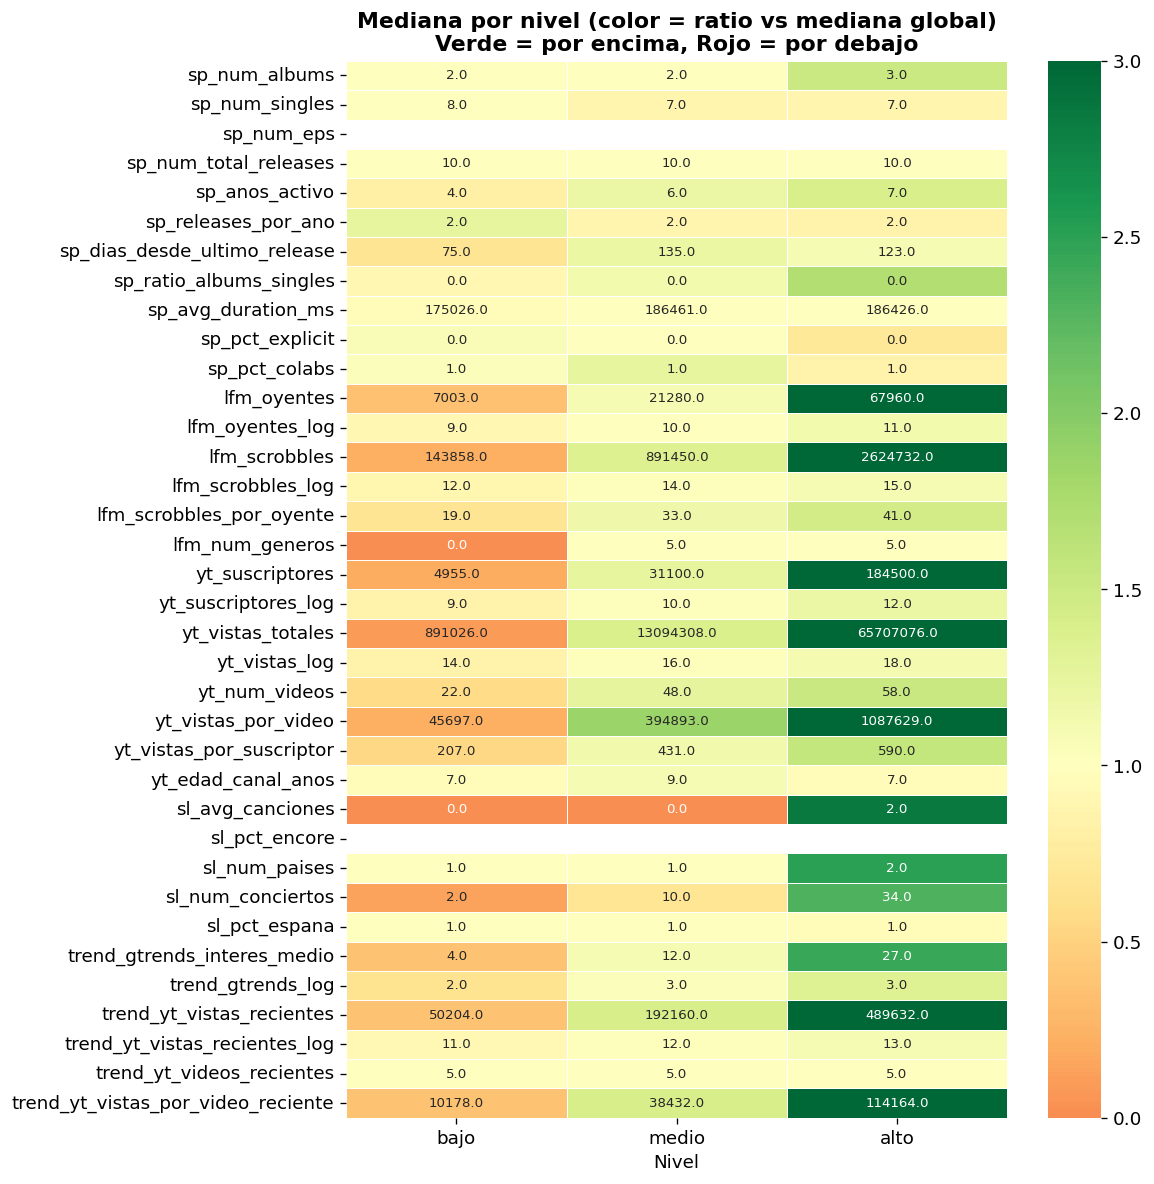

In [11]:
# Mediana de cada feature por nivel
resumen = (
    df.groupby('nivel')[feat_validas]
    .median()
    .reindex(ORDEN)
    .T
)

# Normalizar por la mediana global para ver diferencias relativas
global_median = df[feat_validas].median()
resumen_norm  = resumen.div(global_median.replace(0, np.nan), axis=0)

fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(
    resumen_norm,
    cmap='RdYlGn', center=1, vmin=0, vmax=3,
    annot=resumen.round(0).astype(str),
    fmt='', annot_kws={'size': 8},
    linewidths=0.4, ax=ax
)
ax.set_title('Mediana por nivel (color = ratio vs mediana global)\nVerde = por encima, Rojo = por debajo', fontweight='bold')
ax.set_xlabel('Nivel')
plt.tight_layout()
plt.show()

## 11. Conclusiones del EDA

**157 artistas · 36 features · 3 clases** — EDA ejecutado con el dataset completo.

---

### ✅ Señal general

**27 de 36 features son estadísticamente significativas** (p < 0.05, Kruskal-Wallis).
La mejor feature individual (`lfm_oyentes_log`) alcanza r = 0.63 con el target.
El dataset tiene señal real y sólida — el modelo tiene base para aprender.

---

### 🏆 Features más discriminativas

| Ranking | Feature | H (KW) | r (Spearman) | Interpretación |
|---|---|---|---|---|
| 1 | `lfm_oyentes` / `lfm_oyentes_log` | **61.6** | **+0.63** | Audiencia histórica — señal más potente |
| 2 | `lfm_scrobbles` / `lfm_scrobbles_log` | **59.2** | **+0.62** | Volumen total de escuchas |
| 3 | `yt_suscriptores` / `yt_suscriptores_log` | **53.3** | **+0.59** | Audiencia fiel en YouTube |
| 4 | `yt_vistas_totales` / `yt_vistas_log` | **51.5** | **+0.57** | Popularidad acumulada |
| 5 | `yt_vistas_por_video` | **46.6** | **+0.55** | Engagement medio por vídeo |
| 6 | `yt_vistas_por_suscriptor` | **34.5** | — | Ratio vistas/audiencia |
| 7 | `sl_num_conciertos` | — | **+0.47** | Actividad en directo |

**Last.fm y YouTube dominan la señal.** Ambas fuentes capturan el mismo fenómeno desde ángulos distintos: audiencia acumulada y presencia digital.

---

### 📈 Features de tendencias — evaluación

| Feature | Señal | Decisión |
|---|---|---|
| `trend_gtrends_log` / `trend_gtrends_interes_medio` | Moderada | **Conservar** — captura momentum actual, complementa Last.fm histórico |
| `trend_yt_vistas_recientes_log` / `trend_yt_vistas_recientes` | Moderada | **Conservar** — detecta artistas en ascenso |
| `trend_yt_vistas_por_video_reciente` | Alta correlación con `trend_yt_vistas_recientes_log` (r = 0.996) | **Eliminar en modo lineal** — multicolinealidad casi perfecta |
| `trend_yt_videos_recientes` | Muy baja varianza (casi todos = 5) | **Eliminar** — sin señal discriminativa real |

---

### 🔄 Features con correlación negativa (señales inversas válidas)

- **`sp_releases_por_ano` → r < 0**: artistas emergentes publican más singles/año (estrategia streaming-first). Los artistas grandes lanzan menos pero con más impacto. **Conservar.**
- **`sl_pct_espana` → r < 0**: artistas de nivel alto tienen menor % de conciertos en España porque actúan más en el extranjero. **Conservar.**

---

### ⚠️ Redundancias entre features (pares con |r| > 0.85)

| Par | Correlación |
|---|---|
| raw ↔ log de lfm, yt, trend | **1.000** (transformación monótona) |
| `trend_yt_vistas_por_video_reciente` ↔ `trend_yt_vistas_recientes_log` | **0.996** |
| `lfm_scrobbles` ↔ `lfm_oyentes` | 0.913 |
| `yt_vistas_por_video` ↔ `yt_vistas_log` | 0.907 |
| `sp_ratio_albums_singles` ↔ `sp_num_albums` | 0.899 |
| `sl_pct_espana` ↔ `sl_num_paises` | −0.961 |

**Para árboles**: conservar todas — el modelo selecciona la mejor en cada split.
**Para regresión logística**: usar solo versiones log + RobustScaler + eliminar `trend_yt_vistas_por_video_reciente`.

---

### 🗑️ Features de bajo valor — decisiones definitivas

| Feature | H (KW) | r | Decisión |
|---|---|---|---|
| `sp_num_eps` | ~0 | ~0 | **Eliminar** — sin varianza útil, casi todos tienen 0 |
| `sp_num_total_releases` | ~2 | ~−0.04 | **Eliminar** — redundante con albums + singles |
| `sp_dias_desde_ultimo_release` | ~2 | ~+0.10 | **Eliminar** — no discrimina niveles |
| `yt_edad_canal_anos` | ~1 | ~+0.10 | **Eliminar** — no discrimina niveles |
| `trend_yt_videos_recientes` | ~0 | ~0 | **Eliminar** — casi todos tienen 5, sin varianza real |
| `sp_pct_colabs` | ~10 | ~−0.02 | **Árbol: conservar / Lineal: eliminar** |
| `trend_yt_vistas_por_video_reciente` | — | — | **Árbol: conservar / Lineal: eliminar** (r=0.996 con log) |

---

### 🔺 Outliers destacados

Los outliers son **artistas reales de nivel alto** — no son errores de datos:

| Feature | Artistas extremos |
|---|---|
| `yt_vistas_totales` | Quevedo (1.85B), JC Reyes (1.51B), Bad Gyal (1.48B), RVFV (951M), Natos y Waor (908M) |
| `lfm_scrobbles` | Rels B (27M), Bad Gyal (26M), Quevedo (23M), Rojuu (20M), Yung Beef (19M) |
| `yt_suscriptores` | Rels B (5.4M), Morad (3.65M), Quevedo (2.3M) |
| `trend_yt_vistas_recientes` | JC Reyes (9.5M), RVFV (6.5M), La Pantera (5.4M) |
| `trend_yt_vistas_por_video_reciente` | JC Reyes (1.9M/vídeo), RVFV (1.3M), La Pantera (1.1M) |

⚠️ Outliers anómalos a revisar: `lfm_oyentes_log` / `lfm_scrobbles_log` de **Zeno El Faraón** y **Fernandezz** aparecen como outliers bajos — sus canales de YouTube tenían datos incorrectos y los valores de Last.fm podrían estar contaminados. Verificar antes de entrenar.

**No eliminar** los outliers de nivel alto. Usar **RobustScaler** en regresión logística.

---

### 📋 Decisiones para el preprocesado (`preprocess.py`)

**Imputación de NaN** (setlist ~41% NaN, resto < 5%):
- `sl_num_conciertos`, `sl_num_paises` → **0**
- `sl_avg_canciones`, `sl_pct_encore`, `sl_pct_espana` → **mediana global**
- `yt_vistas_totales`, `yt_num_videos` y derivados → **mediana por nivel**
- `trend_yt_*` sin canal → **0**
- `trend_gtrends_*` sin datos → **mediana por nivel**
- Resto → **0**

**Escalado:**
- Random Forest / XGBoost → **sin escalar**
- Regresión logística / SVM → **RobustScaler**

**Features excluidas en entrenamiento:**
- Siempre: `sp_num_eps`, `sp_num_total_releases`, `sp_dias_desde_ultimo_release`, `yt_edad_canal_anos`, `trend_yt_videos_recientes`
- Solo modo lineal: versiones raw de lfm/yt/trend + `sp_pct_colabs` + `trend_yt_vistas_por_video_reciente`